In [1]:
## In this example, we will study output data frame from pandora.py configuration
#### 1. Opening each data frame and check structure
#### 2. Collect POT and scale factor to the target POT
#### 3. Merge evtdf and mcnudf for further study
#### 4. Draw some plots for each slice and for each pfp


import os
import sys
import lmfit
import numpy as np
import math
import uproot as uproot
import pickle
import pandas as pd
import gc

import matplotlib.pyplot as plt
import matplotlib.colors
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import ticker
from matplotlib.ticker import (AutoMinorLocator, MultipleLocator)
from matplotlib import gridspec

# Absolute path to cafpyana directory
print('Importing cafpyana utils...')
cafpyana_root = "/home/lpelegri/cafpyana"
# Add CAFpyana to the Python search path -- this will allow you to import cafpyana modules
sys.path.insert(0, cafpyana_root)

from analysis_village.unfolding.wienersvd import *
from analysis_village.unfolding.unfolding_inputs import *
from analysis_village.cc1pi.var_configs import *



from analysis_village.cc1pi.HelperFunctions import HelperFunctions
from analysis_village.cc1pi.Constants import CTE as CTE
from analysis_village.cc1pi.CutMasks import CutMasks
from analysis_village.cc1pi.CutMasks.MaskUtils import *
from analysis_village.cc1pi.DataFrameUtils import DFCleaning
from analysis_village.cc1pi.DataFrameUtils.DFLoading import *
from analysis_village.cc1pi.GraphUtils.GraphsUtils import *
from analysis_village.cc1pi.GraphUtils.Utils import *

# import this repo's classes
import pyanalib.pandas_helpers as ph
import pyanalib.split_df_helpers as splh
import pyanalib.stat_helpers as sh

from pyanalib.split_df_helpers import *
from analysis_village.cc1pi.systematics.final_variable_configs import VariableConfig
from analysis_village.cc1pi.systematics.utils import *
from analysis_village.cc1pi.systematics.constants import *
from pyanalib.covariance import *
from analysis_village.cc1pi.DataFrameUtils.DFLoading import *

np.seterr(divide='ignore', invalid='ignore', over='ignore')

Importing cafpyana utils...
Importing cafpyana utils...
data_tot_pot: 4.434e+18
Integrated flux: 6.703e+10
# of targets:  1.2208234852399102e+30
xsec unit:  1.221941885642188e-41


{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

# Load DataFrame MC

In [2]:
from cols_to_keep import *
keys2load = ["cc1pi", "nudf", "hdr", "histpotdf"] ## keys from the configuration file
bnb_path = "/exp/sbnd/data/users/lpelegri/cafpyana_data/cc1pi_1e20_training_update_cv.df"
mc_bnb_df = load_df(bnb_path, keys2load, 100, filter_df = False, reprocess_df = False, reprocess_truth = False)
mc_bnb_evt_df = mc_bnb_df['cc1pi']
mc_bnb_nu_df = mc_bnb_df['nudf']
mc_bnb_hdr_df = mc_bnb_df['hdr']
cols_to_keep = truth_cols_to_keep_slim
del mc_bnb_df
gc.collect()

keys in /exp/sbnd/data/users/lpelegri/cafpyana_data/cc1pi_1e20_training_update_cv.df
Keys: ['/cc1pi_0', '/cc1pi_1', '/cc1pi_2', '/cc1pi_3', '/hdr_0', '/hdr_1', '/hdr_2', '/hdr_3', '/histgenevtdf_0', '/histgenevtdf_1', '/histgenevtdf_2', '/histgenevtdf_3', '/histpotdf_0', '/histpotdf_1', '/histpotdf_2', '/histpotdf_3', '/nudf_0', '/nudf_1', '/nudf_2', '/nudf_3', '/split']
n_split: 4
dataframes
loaded!
5.5469895e+19


378

keys in /exp/sbnd/data/users/lpelegri/cafpyana_data/cc1pi_data_fixdev_bnblight_update_cv.df
Keys: ['/cc1pi_0', '/hdr_0', '/histgenevtdf_0', '/histpotdf_0', '/pot_0', '/split', '/trigger_0']
n_split: 1
dataframes
loaded!
4.5744277e+18
Nothing to update
duplication for /exp/sbnd/data/users/lpelegri/cafpyana_data/cc1pi_data_fixdev_bnblight_update_cv.df


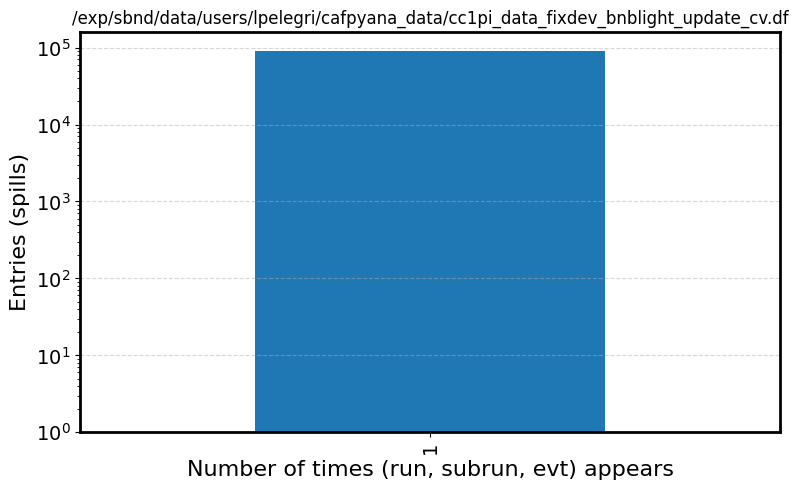

0

In [3]:
#Load data
keys2load = ["cc1pi", "hdr", "histpotdf"] ## keys from the configuration file
data_df = load_df("/exp/sbnd/data/users/lpelegri/cafpyana_data/cc1pi_data_fixdev_bnblight_update_cv.df", keys2load, 100)
data_evt_df = data_df['cc1pi']
data_hdr_df = data_df['hdr']
del data_df
gc.collect()

In [4]:
pot_weight_col = ('slc', 'wgt', '', '', '', '')
# BNB data
data_tot_pot = data_hdr_df['pot'].sum()
print("data_tot_pot: %.3e" %(data_tot_pot))
data_evt_df[pot_weight_col] = np.ones(len(data_evt_df))

# BNB MC
mc_tot_pot = mc_bnb_hdr_df['pot'].sum()
print("mc_tot_pot: %.3e" %(mc_tot_pot))
mc_pot_scale = data_tot_pot / mc_tot_pot
print("mc_pot_scale: %.3e" %(mc_pot_scale))
mc_bnb_evt_df[pot_weight_col] = mc_pot_scale * np.ones(len(mc_bnb_evt_df))

data_tot_pot: 4.574e+18
mc_tot_pot: 5.547e+19
mc_pot_scale: 8.247e-02


In [5]:
mc_evt_df = mc_bnb_evt_df
del mc_bnb_evt_df  # free original immediately — mc_evt_df holds the reference now
gc.collect()
mc_evt_df = perform_truth_matching(mc_evt_df, mc_bnb_nu_df)
del mc_bnb_nu_df

# Test background composition

In [6]:
mc_cumulative_masks = build_event_cumulative_masks(mc_evt_df, sideband = "")
data_cumulative_masks = build_event_cumulative_masks(data_evt_df, sideband = "")

In [7]:
# Loop
for name in mc_cumulative_masks.keys():
    HelperFunctions.print_purity(mc_evt_df[mc_cumulative_masks[name].groupby(['__ntuple', 'entry', 'rec.slc..index']).first()], ('truth','nu_categ','','','',''))

/tmp/ipykernel_98429/1697585615.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  HelperFunctions.print_purity(mc_evt_df[mc_cumulative_masks[name].groupby(['__ntuple', 'entry', 'rec.slc..index']).first()], ('truth','nu_categ','','','',''))


Total weighted slices: 118931.720
Purity (weighted / total weighted)

$\nu_{\mu}$CC1$\pi^{\pm}$: purity: 1.6316%  counts: 1940.528
$\nu_{e}$CC: purity: 0.1282%  counts: 152.481
$\nu_{\mu}$CC0$\pi^{\pm}$0p: purity: 3.0616%  counts: 3641.159
$\nu_{\mu}$CC0$\pi^{\pm}$1p: purity: 7.8253%  counts: 9306.715
$\nu_{\mu}$CC0$\pi^{\pm}2^{+}p$: purity: 2.7455%  counts: 3265.275
$\nu_{\mu}$CC2$^{+}\pi^{\pm}$: purity: 0.4272%  counts: 508.078
NC: purity: 3.9691%  counts: 4720.485
cosmic: purity: 60.3956%  counts: 71829.538
Excluded 1$\mu$1$\pi^{\pm}$: purity: 1.0453%  counts: 1243.188
out-AV $\nu$: purity: 18.7707%  counts: 22324.273


/tmp/ipykernel_98429/1697585615.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  HelperFunctions.print_purity(mc_evt_df[mc_cumulative_masks[name].groupby(['__ntuple', 'entry', 'rec.slc..index']).first()], ('truth','nu_categ','','','',''))


Total weighted slices: 39944.471
Purity (weighted / total weighted)

$\nu_{\mu}$CC1$\pi^{\pm}$: purity: 4.2633%  counts: 1702.941
$\nu_{e}$CC: purity: 0.3289%  counts: 131.370
$\nu_{\mu}$CC0$\pi^{\pm}$0p: purity: 7.5863%  counts: 3030.327
$\nu_{\mu}$CC0$\pi^{\pm}$1p: purity: 20.6045%  counts: 8230.357
$\nu_{\mu}$CC0$\pi^{\pm}2^{+}p$: purity: 7.2366%  counts: 2890.628
$\nu_{\mu}$CC2$^{+}\pi^{\pm}$: purity: 1.0897%  counts: 435.260
NC: purity: 8.1962%  counts: 3273.934
cosmic: purity: 5.9863%  counts: 2391.209
Excluded 1$\mu$1$\pi^{\pm}$: purity: 2.6228%  counts: 1047.659
out-AV $\nu$: purity: 42.0854%  counts: 16810.786


/tmp/ipykernel_98429/1697585615.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  HelperFunctions.print_purity(mc_evt_df[mc_cumulative_masks[name].groupby(['__ntuple', 'entry', 'rec.slc..index']).first()], ('truth','nu_categ','','','',''))


...

Total weighted slices: 389.408
Purity (weighted / total weighted)

$\nu_{\mu}$CC1$\pi^{\pm}$: purity: 73.2105%  counts: 285.088
$\nu_{e}$CC: purity: 0.1059%  counts: 0.412
$\nu_{\mu}$CC0$\pi^{\pm}$0p: purity: 1.1012%  counts: 4.288
$\nu_{\mu}$CC0$\pi^{\pm}$1p: purity: 7.4756%  counts: 29.111
$\nu_{\mu}$CC0$\pi^{\pm}2^{+}p$: purity: 3.3460%  counts: 13.030
$\nu_{\mu}$CC2$^{+}\pi^{\pm}$: purity: 5.0826%  counts: 19.792
NC: purity: 6.4591%  counts: 25.152
cosmic: purity: 0.1271%  counts: 0.495
Excluded 1$\mu$1$\pi^{\pm}$: purity: 2.7742%  counts: 10.803
out-AV $\nu$: purity: 0.3177%  counts: 1.237


/tmp/ipykernel_98429/1697585615.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  HelperFunctions.print_purity(mc_evt_df[mc_cumulative_masks[name].groupby(['__ntuple', 'entry', 'rec.slc..index']).first()], ('truth','nu_categ','','','',''))


Total weighted slices: 374.812
Purity (weighted / total weighted)

$\nu_{\mu}$CC1$\pi^{\pm}$: purity: 74.3454%  counts: 278.656
$\nu_{e}$CC: purity: 0.0880%  counts: 0.330
$\nu_{\mu}$CC0$\pi^{\pm}$0p: purity: 1.1221%  counts: 4.206
$\nu_{\mu}$CC0$\pi^{\pm}$1p: purity: 7.5908%  counts: 28.451
$\nu_{\mu}$CC0$\pi^{\pm}2^{+}p$: purity: 3.3663%  counts: 12.617
$\nu_{\mu}$CC2$^{+}\pi^{\pm}$: purity: 3.8064%  counts: 14.267
NC: purity: 6.5127%  counts: 24.410
cosmic: purity: 0.1320%  counts: 0.495
Excluded 1$\mu$1$\pi^{\pm}$: purity: 2.7063%  counts: 10.143
out-AV $\nu$: purity: 0.3300%  counts: 1.237


/tmp/ipykernel_98429/1697585615.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  HelperFunctions.print_purity(mc_evt_df[mc_cumulative_masks[name].groupby(['__ntuple', 'entry', 'rec.slc..index']).first()], ('truth','nu_categ','','','',''))


Total weighted slices: 371.431
Purity (weighted / total weighted)

$\nu_{\mu}$CC1$\pi^{\pm}$: purity: 74.8224%  counts: 277.913
$\nu_{e}$CC: purity: 0.0888%  counts: 0.330
$\nu_{\mu}$CC0$\pi^{\pm}$0p: purity: 1.1323%  counts: 4.206
$\nu_{\mu}$CC0$\pi^{\pm}$1p: purity: 7.5933%  counts: 28.204
$\nu_{\mu}$CC0$\pi^{\pm}2^{+}p$: purity: 3.2194%  counts: 11.958
$\nu_{\mu}$CC2$^{+}\pi^{\pm}$: purity: 3.8410%  counts: 14.267
NC: purity: 6.5275%  counts: 24.245
cosmic: purity: 0.1332%  counts: 0.495
Excluded 1$\mu$1$\pi^{\pm}$: purity: 2.3091%  counts: 8.577
out-AV $\nu$: purity: 0.3330%  counts: 1.237


In [8]:
# Loop
for name in mc_cumulative_masks.keys():
    n_mc   = get_n_evt(mc_evt_df,   mc_cumulative_masks[name],   use_weight=True)
    n_data = get_n_evt(data_evt_df, data_cumulative_masks[name], use_weight=False)
    print(f"{name:<15} | {n_mc:<12.2f} | {n_data:<12}")

cosmic          | 118931.72    | 210817      
t0              | 39944.47     | 53612       
FV              | 23093.44     | 27923       
nu_score        | 17799.07     | 19228       
track           | 12171.78     | 12030       
chi2            | 2322.60      | 2159        
shower          | 1856.66      | 1822        
angle           | 1639.44      | 1537        
proton_BDT      | 1267.02      | 1211        
containment     | 553.19       | 510         
TPC_containment | 409.45       | 391         
michel          | 389.41       | 363         
extra_pion      | 374.81       | 353         
energy          | 371.43       | 350         


In [9]:
def filter_df(df, extra_mask, cut_mask, config):
    """Applies cut masks without copying — returns a view where possible."""
    mask = cut_mask & mask_dict[extra_mask](df)
    filtered = df.loc[mask]
    if config.first_per_slice:
        # groupby.first() must allocate, unavoidable
        return filtered.groupby(level=SLICE_LEVELS, sort=False).first()
    return filtered  # view, no copy

In [10]:
mask_dict = {
    "none": lambda df: pd.Series(True, index=df.index),
    "pandora_primary": lambda df: CutMasks.is_pandora_primary_mask(df),
    "analysis_primary": lambda df: CutMasks.is_analysis_primary_mask(df),
    "primary_track": lambda df: CutMasks.is_primary_track_mask(df),
    "primary_shower": lambda df: CutMasks.is_primary_shower_mask(df),
    "MIP_candidate": lambda df: CutMasks.is_MIP_candidate_mask(df),
    "contained_MIP_candidate": lambda df: CutMasks.is_MIP_candidate_mask(df) & (df.pfp.is_exiting == False),
    "exiting_MIP_candidate": lambda df: CutMasks.is_MIP_candidate_mask(df) & (df.pfp.is_exiting == True),
    "muon_exiting": lambda df: df.slc.measure_var.muon_contained == False,
    "muon_contained": lambda df: df.slc.measure_var.muon_contained == True,
    "0p": lambda df: df.slc.measure_var.num_protons == 0,
    "1p": lambda df: df.slc.measure_var.num_protons == 1,
    "2plusp": lambda df: df.slc.measure_var.num_protons > 1,
}


In [11]:
cuts = ["cosmic","t0","FV","nu_score","track","chi2","shower","angle","proton_BDT","containment","michel","extra_pion","energy"]

config_angle_between_candidates = FullHistogramConfig(
    file_name = "angle_between_candidates",      
    var_evt_reco_col=('slc','measure_var','angle_between_candidates','','',''),
    truth_column = nu_categ_column,
    first_per_slice = True,
    start_cut = "shower",
    end_cut = "angle",
    bins=np.linspace(0, np.pi, 41),
    xlabel=r'Angle between MIP candidates [rad]',
    cut_value = [CTE.max_angle_between_candidates],
    ylabel=slices_y_label
)

config_analysis_primary_track_score = FullHistogramConfig(
    file_name = "analysis_primary_track_score", 
    var_evt_reco_col=('pfp','trackScore','','','',''),
    truth_column=pfp_truth_column,
    first_per_slice = False,
    start_cut = "nu_score",
    end_cut = "nu_score",
    extra_mask = "analysis_primary",
    bins=np.linspace(0, 1, 41),
    xlabel='analysis primary track score (vtx dist inc.)',
    ylabel= pfps_y_label,
    cut_value = [CTE.min_track_score],
    clip = False
)

config_contained_MIP_candidate_chi2_mu = FullHistogramConfig(
    file_name = "contained_MIP_candidate_chi2_mu", 
    var_evt_reco_col=('pfp','trk','chi2pid','best','chi2_muon',''),
    truth_column=pfp_truth_column,
    first_per_slice = False,
    start_cut = "angle",
    end_cut = "energy",
    extra_mask = "contained_MIP_candidate",
    bins=np.linspace(0, 20, 41),
    xlabel=r'contained MIP candidates $\chi^2_{\mu}$',
    ylabel= pfps_y_label,
    cut_value = [CTE.MIP_candidate_max_muon_score],
    clip = False
)

config_contained_MIP_candidate_chi2_p = FullHistogramConfig(
    file_name = "contained_MIP_candidate_chi2_p", 
    var_evt_reco_col=('pfp','trk','chi2pid','best','chi2_proton',''),
    truth_column=pfp_truth_column,
    first_per_slice = False,
    start_cut = "angle",
    end_cut = "energy",
    extra_mask = "contained_MIP_candidate",
    bins=np.linspace(0, 300, 41),
    xlabel=r'contained MIP candidates $\chi^2_{p}$',
    ylabel= pfps_y_label,
    cut_value = [CTE.MIP_candidate_min_proton_score],
    clip = False
)

config_contained_MIP_candidate_scatter_angle =  FullHistogramConfig(
    file_name = "contained_MIP_candidate_scatter_angle", 
    var_evt_reco_col=('pfp','scatter_angle_ratio','','','',''),
    truth_column=pfp_truth_column,
    first_per_slice = False,
    start_cut = "energy",
    end_cut = "energy",
    extra_mask = "contained_MIP_candidate",
    bins=np.linspace(0, 1, 41),
    xlabel=r'Contained MIP candidates $\frac{MCS max scatter}{MCS total scatter}$',
    ylabel= pfps_y_label
)

config_contained_MIP_candidate_max_daughter_hits = FullHistogramConfig(
    file_name = "contained_MIP_candidate_max_daughter_hits", 
    var_evt_reco_col=('pfp','max_daughter_hits','','','',''),
    truth_column=pfp_truth_column,
    first_per_slice = False,
    start_cut = "energy",
    end_cut = "energy",
    extra_mask = "contained_MIP_candidate",
    bins=np.linspace(10, 300, 41),
    xlabel=r'Contained MIP candidates daughter max hits',
    ylabel= pfps_y_label
)

config_contained_MIP_candidate_frac50 = FullHistogramConfig(
    file_name = "contained_MIP_candidate_frac50", 
    var_evt_reco_col=('pfp','trk','frac50','','',''),
    truth_column=pfp_truth_column,
    first_per_slice = False,
    start_cut = "angle",
    end_cut = "angle",
    extra_mask = "contained_MIP_candidate",
    bins=np.linspace(0, 1, 41),
    xlabel=r'Contained MIP candidates RR frac. with 50% energy',
    ylabel= pfps_y_label
)

config_contained_MIP_candidate_chi2_exp_pol = FullHistogramConfig(
    file_name = "contained_MIP_candidate_chi2_exp_pol", 
    var_evt_reco_col=('pfp','trk','chi2_exp_pol','','',''),
    truth_column=pfp_truth_column,
    first_per_slice = False,
    start_cut = "angle",
    end_cut = "energy",
    extra_mask = "contained_MIP_candidate",
    bins=np.linspace(0, 1, 41),
    xlabel=r'Contained MIP candidates $\chi^2_{pol_0} / \chi^2_{exp}$',
    ylabel= pfps_y_label
)

config_contained_MIP_candidate_bdt_score_proton = FullHistogramConfig(
    file_name = "contained_MIP_candidate_bdt_score_proton", 
    var_evt_reco_col=('pfp','trk','bdt_proton_score','','',''),
    truth_column=pfp_truth_column,
    first_per_slice = False,
    start_cut = "angle",
    end_cut = "energy",
    extra_mask = "contained_MIP_candidate",
    bins=np.linspace(-5, 9, 41),
    xlabel=r'Contained MIP candidates proton BDT score',
    cut_value = [CTE.BDT_proton_max_score],
    ylabel= pfps_y_label
)

config_contained_MIP_candidate_bdt_score_muon_pion = FullHistogramConfig(
    file_name = "contained_MIP_candidate_bdt_score_muon_pion", 
    var_evt_reco_col=('pfp','trk','bdt_muon_pion_score','','',''),
    truth_column=pfp_truth_column,
    first_per_slice = False,
    start_cut = "energy",
    end_cut = "energy",
    extra_mask = "contained_MIP_candidate",
    bins=np.linspace(-5, 7, 41),
    xlabel=r'Contained MIP candidates $\mu/\pi$ separation BDT score',
    ylabel= pfps_y_label
)


measure_var_vec = [
    config_angle_between_candidates,
]

particle_vars_vec = [
    config_contained_MIP_candidate_bdt_score_muon_pion,
    config_primary_track_chi2_mu,
    config_primary_track_chi2_p,
    config_contained_MIP_candidate_chi2_mu,
    config_contained_MIP_candidate_chi2_p,
    config_contained_MIP_candidate_scatter_angle, 
    config_contained_MIP_candidate_frac50,
    config_contained_MIP_candidate_chi2_exp_pol,
    config_contained_MIP_candidate_bdt_score_proton
]



In [12]:
def get_stat_covariance_matrix(cv_contents, sum_w2):
    """
    cv_contents: array of bin contents (sum of weights)
    sum_w2: array of the sum of the squares of the weights per bin
    """
    cv_contents = np.asarray(cv_contents)
    sum_w2 = np.asarray(sum_w2)
    n_bins = len(cv_contents)

    # 1. Variance for weighted Poisson is Sum(W^2)
    cov = np.diag(sum_w2)

    # 2. Fractional covariance: Var / (Content^2) = Sum(W^2) / (Sum W)^2
    with np.errstate(divide='ignore', invalid='ignore'):
        # This is the squared fractional error
        frac_variance = np.where(cv_contents > 0, sum_w2 / (cv_contents**2), 0.0)
        cov_frac = np.diag(frac_variance)

    # 3. Correlation matrix
    corr = np.eye(n_bins)

    return {
        "cov": cov,
        "cov_frac": cov_frac,
        "corr": corr,
    }

In [13]:

def add_approval_text(approval, textloc_x, textloc_y, textloc_ha, fontsize = 16, ax=None):
    if approval == "internal":
        approval_text = r"$\mathbf{SBND}$ Internal"
        textcolor = 'rosybrown'
    elif approval == "preliminary":
        approval_text = r"$\mathbf{SBND}$ Preliminary"
        textcolor = 'gray'
    elif approval == "AnalysisInProgress":
        approval_text = r"$\mathbf{SBND}$ Analysis in Progress"
        textcolor = 'gray'
    else:
        return # don't add anything

    if ax is None:
        ax = plt.gca()  
    ax.text(
        textloc_x, textloc_y, 
        approval_text, 
        transform=ax.transAxes, 
        ha=textloc_ha, va='bottom',  # Changed to 'bottom' so we stack upwards cleanly
        fontsize=fontsize, color=textcolor # Fixed: now using the color assigned by the status
    )


def add_genie_version_text(textloc_x, textloc_y, textloc_ha, fontsize = 13.5, ax=None):
    if ax is None:
        ax = plt.gcf().axes[0]  
    ax.text(textloc_x, textloc_y, 
            r"GENIE v3.4.0 AR23_00i_00_000", 
            transform=ax.transAxes, 
            ha=textloc_ha, va='bottom', # Changed to 'bottom'
            fontsize=fontsize, color='gray')


def add_exposure_text(textloc_x, textloc_y, textloc_ha, fontsize = 13.5, ax=None, data_pot =1e20):
    if ax is None:
        ax = plt.gcf().axes[0]  
    ax.text(textloc_x, textloc_y, 
            f"BNB Exposure: {data_pot:.2e} POT", 
            transform=ax.transAxes, 
            ha=textloc_ha, va='bottom', # Changed to 'bottom'
            fontsize=fontsize, color='gray')


def plot_stacked_histogram_with_ratio(
    mc_df,
    data_df,
    config,
    cov_frac_matrix=None,
    cov_matrix=None,
    title: str = None,
    weight_column: tuple = None,
    data_pot: float = None,
    normalize: bool = False,
    show_stats: bool = True,
    symmetric_ratio: bool = False,
    divide_by_bin_width: bool = False,
    skip_bin_compression: bool = False
):
    # ==========================================
    # 1. PRE-PROCESSING AND SCALING
    # ==========================================
    slice_levels = ['__ntuple', 'entry', 'rec.slc..index']
    if config.first_per_slice:
        mc_df   = mc_df.groupby(level=slice_levels, sort=False).first()
        data_df = data_df.groupby(level=slice_levels, sort=False).first()

    mc_data    = mc_df[config.var_evt_reco_col]
    mc_types   = mc_df[config.truth_column]
    mc_weights = mc_df[weight_column] if weight_column in mc_df.columns else pd.Series(1.0, index=mc_df.index)

    # --- Palette Selection ---
    present_categories = set(mc_types.dropna().unique())
    palettes = [category_colors, category_colors_pfp, proton_distinction_category_colors, genie_category_colors]
    chosen_map, max_overlap = category_colors, -1
    for p in palettes:
        overlap = len(present_categories.intersection(p.keys()))
        if overlap > max_overlap:
            max_overlap = overlap
            chosen_map  = p

    # ==========================================
    # 2. SORTING CATEGORIES
    # ==========================================
    category_totals = [(t, mc_weights[mc_types == t].sum()) for t in mc_types.dropna().unique()]
    signal_keys     = ["CC1pi"]
    if config.truth_column == ('truth','genie_categ','','','',''):
        signal_keys = ["nu_mu_CC_Res"]
        
    signals     = sorted([x for x in category_totals if     x[0] in signal_keys], key=lambda x: x[1], reverse=True)
    backgrounds = sorted([x for x in category_totals if not x[0] in signal_keys], key=lambda x: x[1], reverse=True)

    sorted_types   = [x[0] for x in backgrounds + signals]
    stack_data_mc  = [mc_data[mc_types == t].dropna() for t in sorted_types]
    stack_weights  = [mc_weights[mc_types == t].loc[mc_data[mc_types == t].dropna().index] for t in sorted_types]

    # --- TRUE PHYSICS BIN TRACKING ---
    true_bins = np.array(config.bins).astype(float)
    max_bin_edge = true_bins[-1]
    bin_widths = np.diff(true_bins)
    total_true_width = true_bins[-1] - true_bins[0]

    # --- EXCEPTION 1: Check for 'all_evts' ---
    var_identifier   = config.file_name
    skip_compression = (var_identifier == "all_evts") or (len(config.bins) <= 2) or skip_bin_compression

    # --- AUTO-SCALING VISUAL BINS (MAX 50% CONSTRAINT) ---
    visual_bins = [true_bins[0]]
    compressed_indices = [] 
    
    if skip_compression:
        visual_bins = true_bins.copy()
    else:
        is_bloated = bin_widths >= (0.50 * total_true_width)
        num_bloated = np.sum(is_bloated)
        
        bloated_budget_fraction = 0.50 * num_bloated
        normal_budget_fraction = 1.0 - bloated_budget_fraction
        
        sum_normal_true_widths = np.sum(bin_widths[~is_bloated])
        if sum_normal_true_widths == 0: 
            sum_normal_true_widths = 1.0

        current_visual_coord = true_bins[0]
        for i in range(len(bin_widths)):
            if is_bloated[i]:
                visual_width = 0.50 * total_true_width
                compressed_indices.append(i)
            else:
                fraction_of_normal = bin_widths[i] / sum_normal_true_widths
                visual_width = fraction_of_normal * (normal_budget_fraction * total_true_width)
                
            current_visual_coord += visual_width
            visual_bins.append(current_visual_coord)
        
    visual_bins = np.array(visual_bins)
    visual_bin_centers = (visual_bins[:-1] + visual_bins[1:]) / 2
    visual_bin_widths  = np.diff(visual_bins)

    def map_to_visual_coordinates(data_series):
        if skip_compression:
            return np.clip(data_series, true_bins[0], max_bin_edge) if config.clip else data_series
            
        if not config.clip:
            clipped = data_series
        else:
            clipped = np.clip(data_series, true_bins[0], max_bin_edge)
        
        indices = np.digitize(clipped, true_bins) - 1
        indices = np.clip(indices, 0, len(true_bins) - 2)
        
        fractional_pos = (clipped - true_bins[indices]) / bin_widths[indices]
        visual_coords = visual_bins[indices] + fractional_pos * visual_bin_widths[indices]
        return visual_coords

    stack_mc_visual = [map_to_visual_coordinates(d) for d in stack_data_mc]

    # ==========================================
    # 3. SETUP FIGURE
    # ==========================================
    fig      = plt.figure(figsize=(10, 8))
    gs       = gridspec.GridSpec(2, 1, height_ratios=[4, 1], hspace=0.07)
    ax_top   = fig.add_subplot(gs[0])
    ax_ratio = fig.add_subplot(gs[1], sharex=ax_top)

    colors         = [chosen_map.get(t, "#7f7f7f") for t in sorted_types]
    all_mc_weights = pd.concat(stack_weights)

    mc_sum, _ = np.histogram(pd.concat(stack_mc_visual), bins=visual_bins, weights=all_mc_weights)

    # --- MC UNCERTAINTY ---
    if cov_frac_matrix is not None:
        frac_err = np.sqrt(np.diag(cov_frac_matrix))
        mc_error = frac_err * mc_sum
    else:
        mc_sum_w2, _ = np.histogram(pd.concat(stack_mc_visual), bins=visual_bins, weights=all_mc_weights ** 2)
        mc_error         = np.sqrt(mc_sum_w2)
        stat_cov         = get_stat_covariance_matrix(mc_sum, mc_sum_w2)
        cov_matrix       = stat_cov["cov"]
        cov_frac_matrix  = stat_cov["cov_frac"]

    if normalize:
        norm_fact = mc_sum.sum()
        if norm_fact > 0:
            mc_sum    /= norm_fact
            mc_error  /= norm_fact
            stack_weights = [w / norm_fact for w in stack_weights]

    # --- DATA ---
    cols_to_check = [config.var_evt_reco_col]
    if weight_column in data_df.columns:
        cols_to_check.append(weight_column)
    valid_df     = data_df.dropna(subset=cols_to_check)
    data         = valid_df[config.var_evt_reco_col]
    data_weights = valid_df[weight_column] if weight_column in valid_df.columns else np.ones(len(data))

    data_visual = map_to_visual_coordinates(data)
    data_counts, _ = np.histogram(data_visual, bins=visual_bins, weights=data_weights)
    data_sum_w2, _ = np.histogram(data_visual, bins=visual_bins, weights=data_weights ** 2)

    if normalize:
        denom            = len(data) if len(data) > 0 else 1
        data_plot_counts = data_counts / denom
        data_errors      = np.sqrt(data_sum_w2) / denom
    else:
        data_plot_counts = data_counts.astype(float)
        data_errors      = np.sqrt(data_sum_w2)

    # ==========================================
    # 4. STATISTICS & PLOTTING
    # ==========================================
    ret_stats_data_rate = get_stat_covariance_matrix(data_plot_counts, data_sum_w2)
    chi2_val, ndof, p_val = get_chi2(data_counts, mc_sum, cov_matrix + ret_stats_data_rate["cov"])

    if divide_by_bin_width:
        mc_sum           /= bin_widths
        mc_error         /= bin_widths
        data_plot_counts /= bin_widths
        data_errors      /= bin_widths
        
        new_stack_weights = []
        for i, d in enumerate(stack_data_mc):
            clipped_d = np.clip(d, true_bins[0], max_bin_edge) if config.clip else d
            bin_indices = np.clip(np.digitize(clipped_d, true_bins) - 1, 0, len(bin_widths) - 1)
            new_stack_weights.append(stack_weights[i] / bin_widths[bin_indices])
        stack_weights = new_stack_weights

    ax_top.hist(stack_mc_visual, bins=visual_bins, stacked=True, weights=stack_weights,
                histtype='stepfilled', color=colors, alpha=0.3)
    ax_top.hist(stack_mc_visual, bins=visual_bins, stacked=True, weights=stack_weights,
                histtype='step', color=colors, linewidth=2)
    
    ax_top.bar(visual_bin_centers, 2 * mc_error, bottom=mc_sum - mc_error, width=visual_bin_widths,
                edgecolor='grey', facecolor='grey', alpha=0.2, linewidth=0)
    ax_top.bar(visual_bin_centers, 2 * mc_error, bottom=mc_sum - mc_error, width=visual_bin_widths,
                edgecolor='grey', facecolor='none', hatch='////', alpha=0.5, linewidth=0)
    ax_top.errorbar(visual_bin_centers, data_plot_counts, yerr=data_errors, xerr=visual_bin_widths / 2,
                    fmt='ko', markersize=6, zorder=10, capsize=0)

    # ==========================================
    # 5. RATIO SUBPLOT
    # ==========================================
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio       = np.divide(data_plot_counts, mc_sum, out=np.zeros_like(data_plot_counts), where=mc_sum != 0)
        ratio_error = np.divide(data_errors,       mc_sum, out=np.zeros_like(data_errors),       where=mc_sum != 0)
        mc_rel_error = np.divide(mc_error,          mc_sum, out=np.zeros_like(mc_error),           where=mc_sum != 0)

    valid_ratio = mc_sum > 0
    if np.any(valid_ratio) and symmetric_ratio:
        data_extrema  = np.maximum(
            np.abs((ratio[valid_ratio] + ratio_error[valid_ratio]) - 1),
            np.abs((ratio[valid_ratio] - ratio_error[valid_ratio]) - 1)
        )
        mc_extrema    = mc_rel_error[valid_ratio]
        max_deviation = np.max(np.maximum(data_extrema, mc_extrema))
        y_padding     = max(max_deviation * 1.4, 0.1)
        ax_ratio.set_ylim(1 - y_padding, 1 + y_padding)
    elif np.any(valid_ratio):
        max_deviation = np.max(np.abs(ratio[valid_ratio] - 1) + ratio_error[valid_ratio])
        y_padding     = max(min(max_deviation * 1.4, 0.75), 0.1)
        ax_ratio.set_ylim(1 - y_padding, 1 + y_padding)
    else:
        ax_ratio.set_ylim(0.5, 1.5)

    ax_ratio.bar(visual_bin_centers, 2 * mc_rel_error, bottom=1 - mc_rel_error, width=visual_bin_widths,
                 edgecolor='grey', facecolor='grey', alpha=0.2, linewidth=0)
    ax_ratio.bar(visual_bin_centers, 2 * mc_rel_error, bottom=1 - mc_rel_error, width=visual_bin_widths,
                 edgecolor='grey', facecolor='none', hatch='////', alpha=0.4, linewidth=0)
    ax_ratio.errorbar(visual_bin_centers, ratio, yerr=ratio_error, xerr=visual_bin_widths / 2,
                      fmt='ko', markersize=6, capsize=0)
    ax_ratio.axhline(1.0, color='#d62728', linestyle='--', linewidth=2)

    # --- VERTICAL CUT LINE ---
    cut_val  = getattr(config, 'cut_value', None)
    draw_cut = False
    if cut_val is not None:
        draw_cut = (
            any(v != -999 for v in cut_val)
            if isinstance(cut_val, (list, np.ndarray))
            else (cut_val != -999)
        )

    cut_hand = Line2D([0], [0], color='black', linestyle='--', linewidth=2, label='Selection Cut')
    if draw_cut:
        cuts_to_draw = cut_val if isinstance(cut_val, (list, np.ndarray)) else [cut_val]
        for ax in [ax_top, ax_ratio]:
            for val in cuts_to_draw:
                if val != -999:
                    if skip_compression:
                        v_cut = val
                    else:
                        indices = np.digitize(val, true_bins) - 1
                        indices = np.clip(indices, 0, len(true_bins) - 2)
                        fractional_pos = (val - true_bins[indices]) / bin_widths[indices]
                        v_cut = visual_bins[indices] + fractional_pos * visual_bin_widths[indices]
                    ax.axvline(v_cut, color='black', linestyle='--', linewidth=2, zorder=2)

    # ==========================================
    # 6. LEGEND ENGINE DECLARATION
    # ==========================================
    total_data_counts = len(data_clipped) if 'data_clipped' in locals() else len(data)
    mc_hand  = [Patch(facecolor=to_rgba(chosen_map.get(t, "#7f7f7f"), 0.3),
                      edgecolor=chosen_map.get(t, "#7f7f7f"),
                      label=bkg_name_nice_map.get(t, t)) for t in sorted_types]
    err_label = 'Prelim. Total Unc.' if show_stats else 'MC Stat. Error'
    err_hand  = Patch(edgecolor='grey', facecolor='none', hatch='////', alpha=0.5, label=err_label)
    dat_hand  = Line2D([0], [0], color='black', marker='o', linestyle='', label='Data', markersize=8)

    all_handles = mc_hand + [err_hand, dat_hand]
    all_labels  = [h.get_label() for h in mc_hand] + [err_label, 'Data']

    if draw_cut:
        all_handles.append(cut_hand)
        all_labels.append(cut_hand.get_label())

    if show_stats:
        if ndof > 0 and chi2_val is not None:
            chi2_str = f"$\\chi^{{2}}$ / ndf = {chi2_val/ndof:.3f}"
        else:
            chi2_str = f"$\\chi^{{2}}$: N/A"
        p_value_str      = f"$p_{{\\mathrm{{value}}}}$ = {p_val:.3f}" if p_val is not None else "$p$: N/A"
        data_str         = f'$N_{{\\mathrm{{Data}}}}$ = {total_data_counts}'
        chi2_handle      = Patch(color='none', label=chi2_str)
        p_value_handle   = Patch(color='none', label=p_value_str)
        N_data_evts_handle = Patch(color='none', label=data_str)
        all_handles += [chi2_handle, p_value_handle, N_data_evts_handle]
        all_labels  += [chi2_str, p_value_str, data_str]

    n_cols = (len(all_handles) + 3) // 4
    leg = ax_top.legend(
        handles=all_handles, labels=all_labels,
        loc='upper ' + config.stats_horizontal_alignment, ncol=n_cols,
        fontsize=12, framealpha=1.0, edgecolor='black', fancybox=False,
        borderaxespad=1, columnspacing=1.5, handlelength=1.5, handletextpad=0.5,
    )
    leg.get_frame().set_linewidth(1.5)

    # ==========================================
    # 7. FINAL STYLING & TICK LABEL OVERRIDES
    # ==========================================
    ax_top.set_xlim(visual_bins[0], visual_bins[-1])
    ax_top.set_ylim(0, ax_top.get_ylim()[1] * 1.4)
    
    if var_identifier == "all_evts":
        ax_top.set_ylim(0, ax_top.get_ylim()[1] * 1.25)

     # --- DYNAMIC TICK CONFIGURATIONS ---
    if var_identifier == "num_protons_two":
        tick_positions = visual_bin_centers
        tick_labels = [f"{int(val)}" for val in true_bins[:-1]]
        if len(tick_labels) > 0:
            tick_labels[-1] = r"N"
        ax_ratio.set_xticks(tick_positions)
        ax_ratio.set_xticklabels(tick_labels, fontsize=14)
    elif var_identifier == "num_protons":
        tick_positions = visual_bin_centers
        tick_labels = [f"{int(val)}" for val in true_bins[:-1]]
        if len(tick_labels) > 0:
            tick_labels[-1] = r"$\geq$" + f"{int(true_bins[-2])}"
        ax_ratio.set_xticks(tick_positions)
        ax_ratio.set_xticklabels(tick_labels, fontsize=14)
    elif not skip_bin_compression:
        tick_positions = visual_bins
        tick_labels = [f"{val:.2f}".rstrip('0').rstrip('.') for val in true_bins]
        ax_ratio.set_xticks(tick_positions)
        ax_ratio.set_xticklabels(tick_labels, fontsize=14)
        
    ylabel = config.ylabel
    if divide_by_bin_width & (var_identifier != "all_evts") & (var_identifier != "num_protons"):
        ylabel += " / Bin width"

    ax_top.set_ylabel(f"{ylabel}")
    ax_ratio.set_ylabel("Data/MC")
    ax_ratio.set_xlabel(config.xlabel, fontsize=20)
    ax_ratio.tick_params(axis='x', which='both', direction='inout', length=6)

    # Optional: Optional custom title handling (uncomment if required)
    # if title is not None:
    #     ax_top.set_title(title, fontsize=18, pad=15)

    plt.setp(ax_top.get_xticklabels(), visible=False)
    fig.align_ylabels([ax_top, ax_ratio])
    
    # Finalize visual borders before extraction 
    plt.subplots_adjust(top=0.92, bottom=0.12, left=0.12, right=0.95, hspace=0.07)

    # ==========================================
    # 8. GEOMETRY-LOCKED RENDERING (TEXT & AXIS BREAKS)
    # ==========================================
    # Freeze canvas dimensions to accurately map pixels to relative axis scale
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    
    # --- A. Axis Break Slashes ---
    if not skip_compression and len(compressed_indices) > 0:
        for bin_idx in compressed_indices:
            break_x_data = visual_bin_centers[bin_idx]
            for ax in [ax_top, ax_ratio]:
                display_x, _ = ax.transData.transform((break_x_data, ax.get_ylim()[0]))
                x_fig = fig.transFigure.inverted().transform((display_x, 0))[0]
                display_y = ax.transAxes.transform((0, 0))[1]
                y_fig = fig.transFigure.inverted().transform((0, display_y))[1]
                
                slash_dx = 0.008
                slash_dy = 0.012
                for offset in [-0.003, 0.003]:  
                    l = Line2D(
                        [x_fig + offset - slash_dx, x_fig + offset + slash_dx],
                        [y_fig - slash_dy,           y_fig + slash_dy],
                        color='black', linewidth=1.5,
                        transform=fig.transFigure,
                        clip_on=False,
                        zorder=30
                    )
                    fig.add_artist(l)

    # --- B. Compute Legend Dimensions ---
    leg_bbox = leg.get_window_extent(renderer)
    inv_axes = ax_top.transAxes.inverted()
    
    is_left = config.stats_horizontal_alignment.lower() == "left"
    pixel_x = leg_bbox.x0 if is_left else leg_bbox.x1
    ha_style = 'left' if is_left else 'right'
    
    bottom_corner_in_axes = inv_axes.transform((pixel_x, leg_bbox.y0))
    leg_bottom_x = bottom_corner_in_axes[0]
    leg_bottom_y = bottom_corner_in_axes[1]

    # --- C. Add Watermark Texts anchored to legend in axes coords ---
    plt.draw()
    renderer  = fig.canvas.get_renderer()
    leg_bbox  = leg.get_window_extent(renderer)
    inv_axes  = ax_top.transAxes.inverted()
    
    is_left  = config.stats_horizontal_alignment.lower() == "left"
    ha_style = 'left' if is_left else 'right'
    
    # Convert both x and y of legend bottom corner to axes fraction
    leg_x_ax, leg_y_ax = inv_axes.transform(
        (leg_bbox.x0 if is_left else leg_bbox.x1, leg_bbox.y0)
    )
    
    # Convert the fixed pixel offsets (-0.06, -0.10, -0.14) to axes fraction
    # by measuring one axes unit in pixels
    axes_height_px = ax_top.get_window_extent(renderer).height
    offset_per_unit = 1.0 / axes_height_px  # 1 pixel in axes fraction
    
    # Use a fixed point size offset instead of hardcoded axes fractions
    # 14pt font ≈ 19px at 100dpi; use 1.5× line spacing
    line_height_ax = (14 * 1.5) * offset_per_unit
    
    for i, (fn, fs) in enumerate([
        (add_approval_text,     14  ),
        (add_genie_version_text, 11.5),
        (add_exposure_text,      11.5),
    ]):
        kwargs = dict(
            textloc_x=leg_x_ax,
            textloc_y=leg_y_ax - (i + 1) * line_height_ax * 1.2,
            textloc_ha=ha_style,
            ax=ax_top,
            fontsize=fs,
        )
        if fn == add_exposure_text:
            kwargs['data_pot'] = data_pot
        if fn == add_approval_text:
            kwargs['approval'] = "AnalysisInProgress"
        fn(**kwargs)

    # --- D. Shift Statistics Strings ---
    if show_stats:
        texts = leg.get_texts()
        for t in texts[-3:]:
            t.set_position((-28, 0))

    # Safe display
    plt.show()
    return fig, p_val


In [14]:
def signal_hists(evtdf=None,
                 nudf=None,
                 var_config=None,
                 return_data=False,
                 plot=True,
                 textloc=[0.05, 0.55],
                 approval="internal",
                 save_fig=False,
                 save_name=None):

    bins     = var_config.bins
    reco_col = var_config.var_evt_reco_col
    get_fn   = get_clipped_evts if var_config.clip else get_evts

    # All selected — view, no copy
    var_allsel_reco, wgt_allsel_reco = get_fn(evtdf, reco_col, bins)

    # Signal mask — use loc to avoid copying the full df
    sig_mask = evtdf.truth.nu_categ == "CC1pi"  # boolean array only
    var_sel_reco  = var_allsel_reco[sig_mask]   # masked view into numpy array
    wgt_sel_reco  = wgt_allsel_reco[sig_mask]
    del sig_mask

    # Single-pass: compute sum_w and sum_w2 together
    nevts_allsel_reco,  _ = np.histogram(var_allsel_reco, weights=wgt_allsel_reco,    bins=bins)
    sum_w2_allsel_reco, _ = np.histogram(var_allsel_reco, weights=wgt_allsel_reco**2, bins=bins)
    del var_allsel_reco  # free before allocating signal histograms

    nevts_sel_reco,  _ = np.histogram(var_sel_reco, weights=wgt_sel_reco,    bins=bins)
    sum_w2_sel_reco, _ = np.histogram(var_sel_reco, weights=wgt_sel_reco**2, bins=bins)

    if return_data:
        return {
            "var_sel_reco":        var_sel_reco,
            "wgt_sel_reco":        wgt_sel_reco,
            "nevts_sel_reco":      nevts_sel_reco,
            "sum_w2_sel_reco":     sum_w2_sel_reco,
            "nevts_allsel_reco":   nevts_allsel_reco,
            "sum_w2_allsel_reco":  sum_w2_allsel_reco,
        }
    # if not return_data, all locals go out of scope here and are freed

--- Processing Cut: energy ---


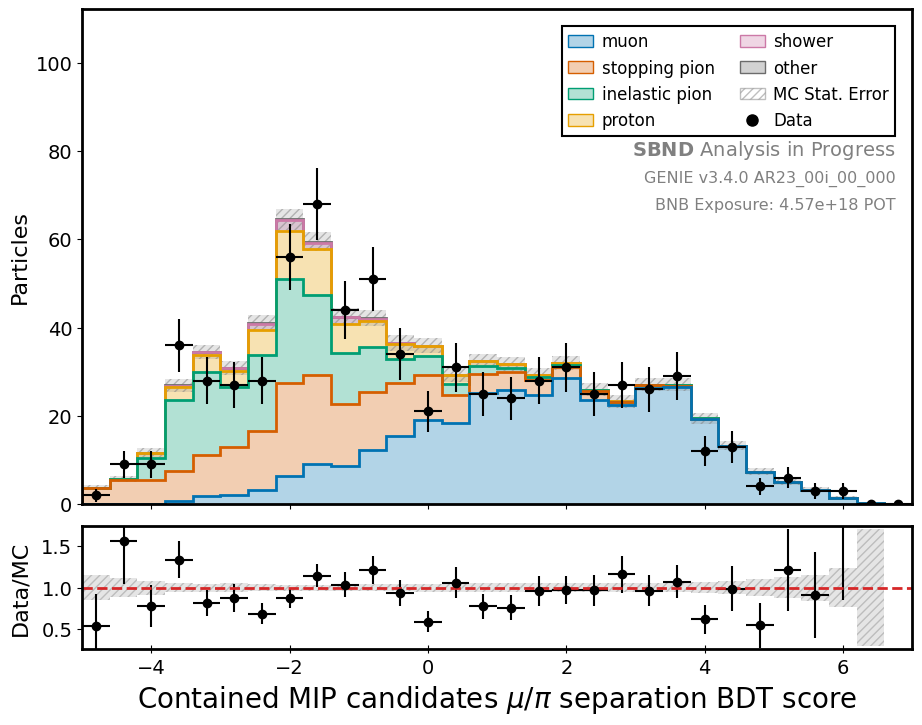

--- Processing Cut: track ---


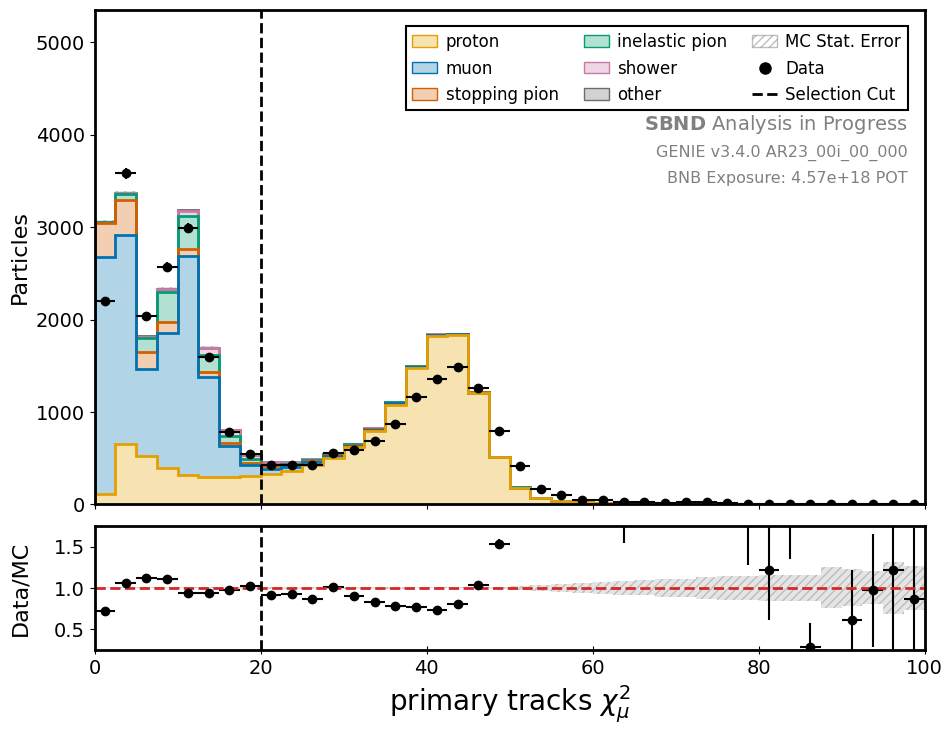

--- Processing Cut: chi2 ---


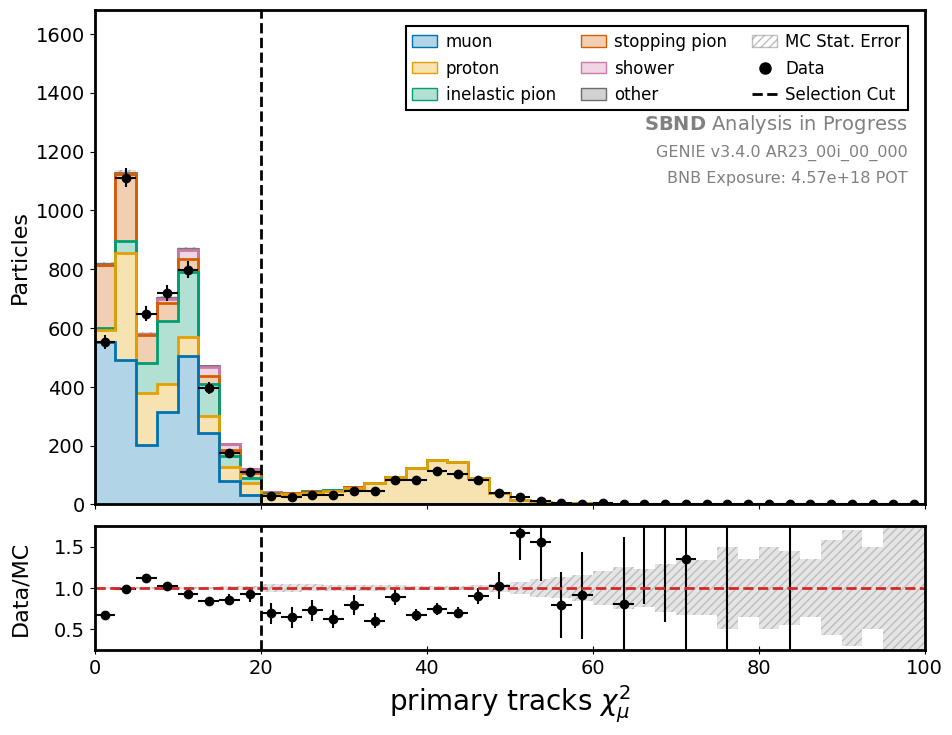

--- Processing Cut: track ---


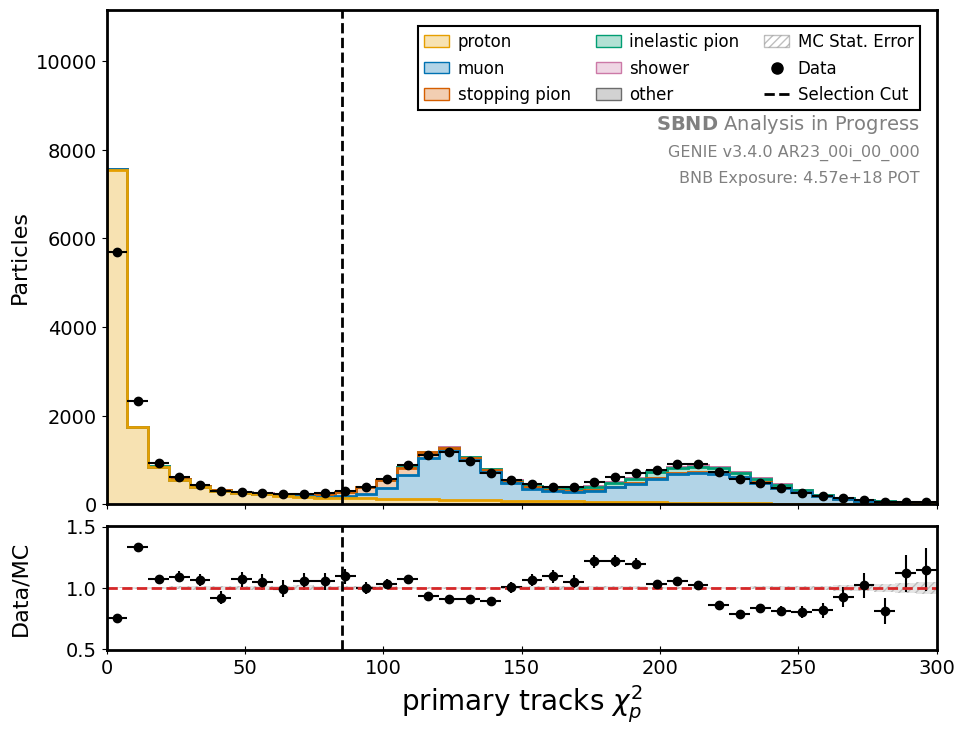

--- Processing Cut: chi2 ---


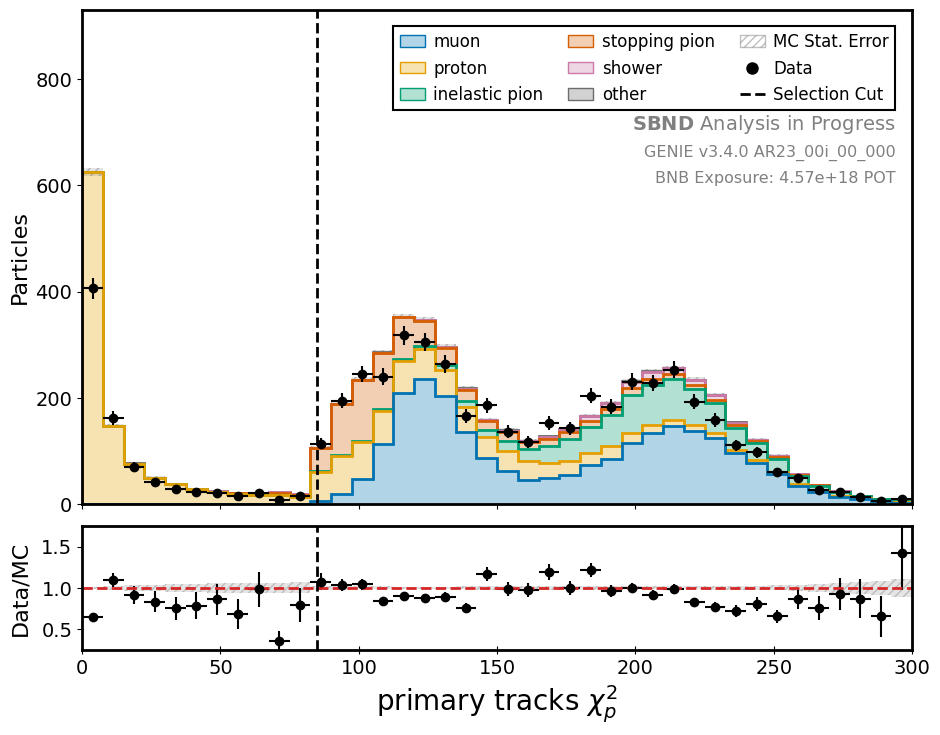

--- Processing Cut: angle ---


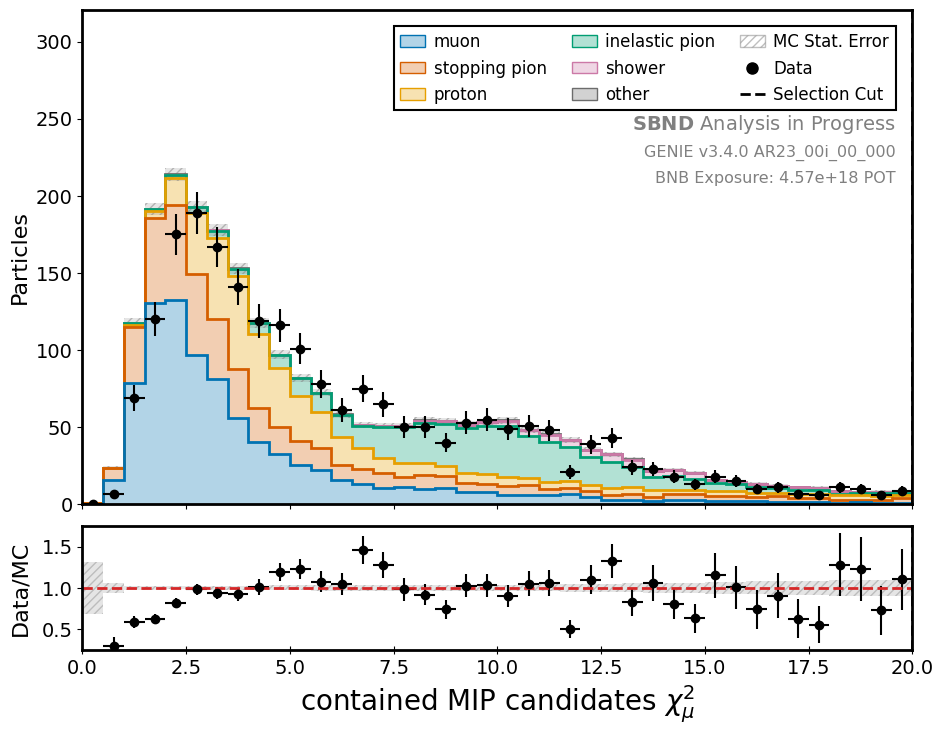

--- Processing Cut: proton_BDT ---


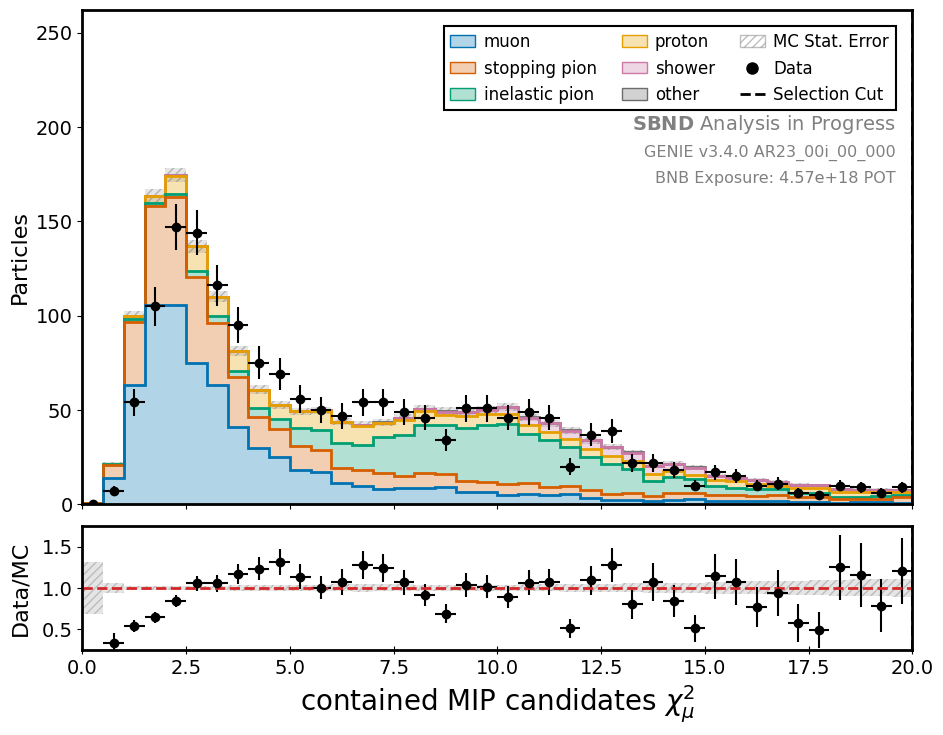

--- Processing Cut: containment ---


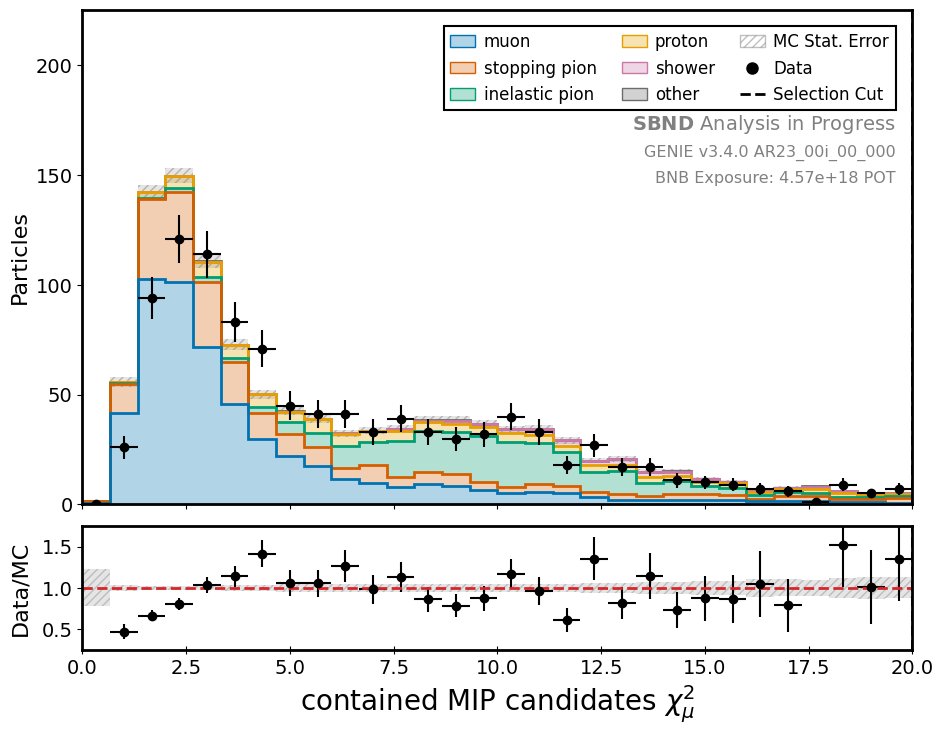

--- Processing Cut: michel ---


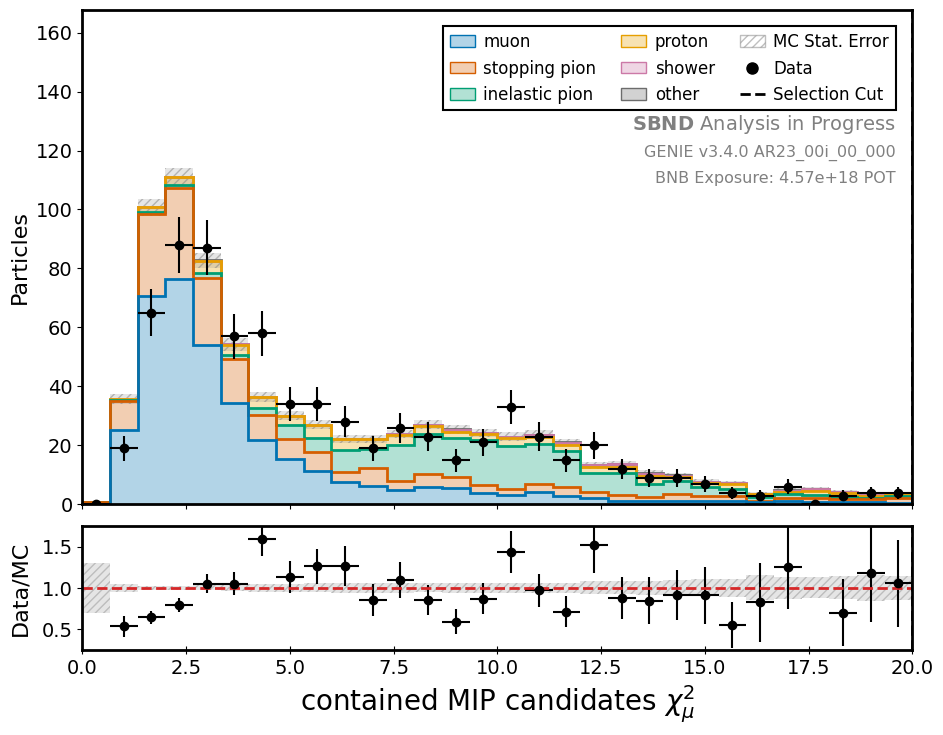

--- Processing Cut: extra_pion ---


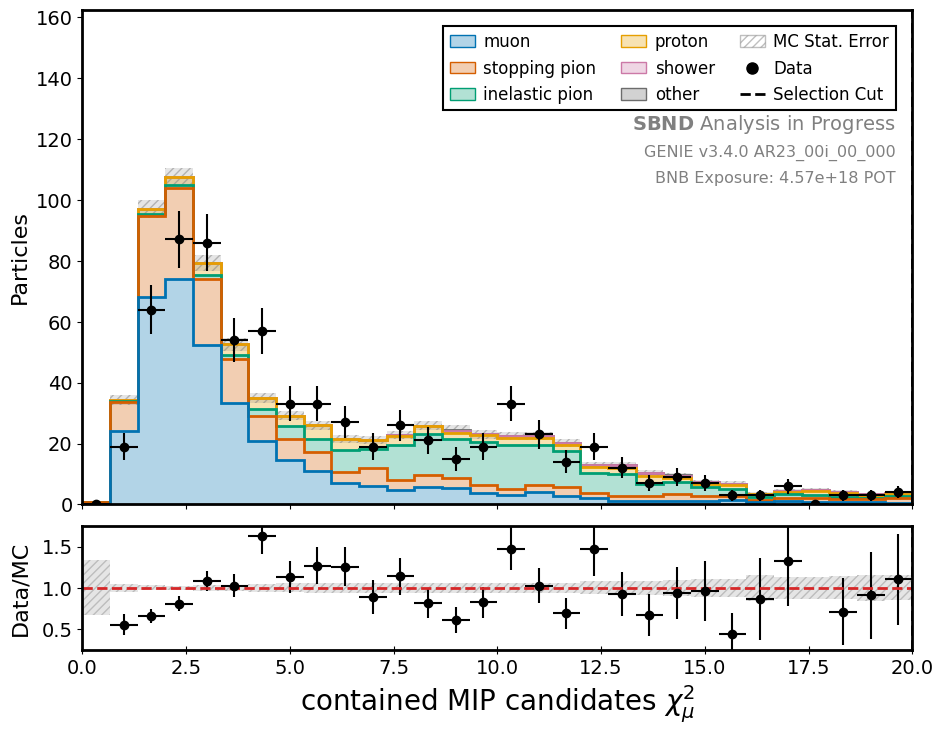

--- Processing Cut: energy ---


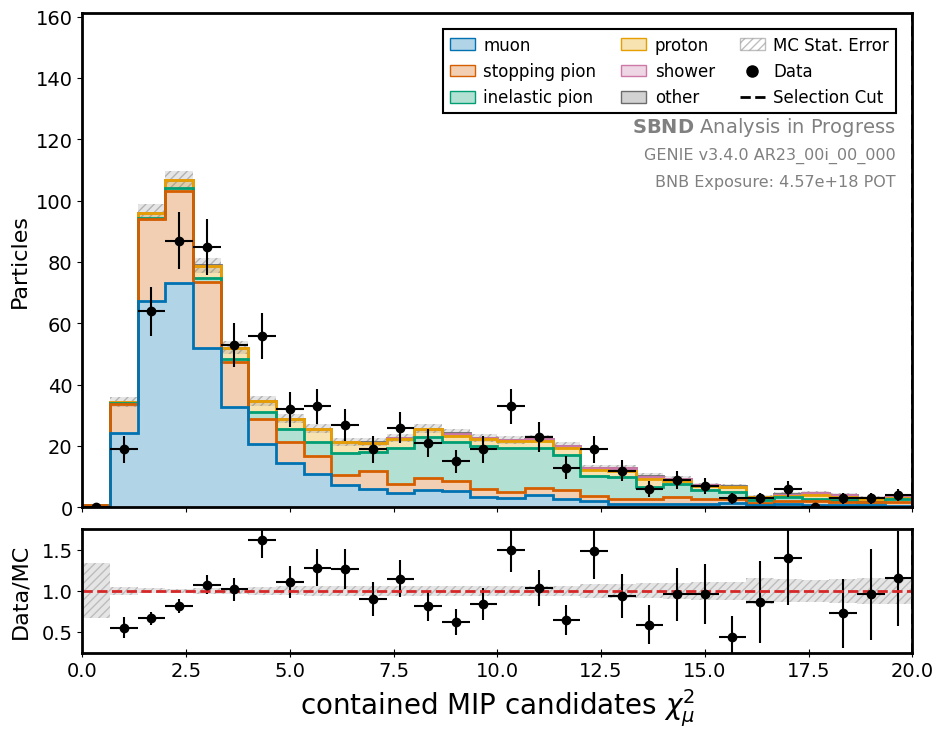

--- Processing Cut: angle ---


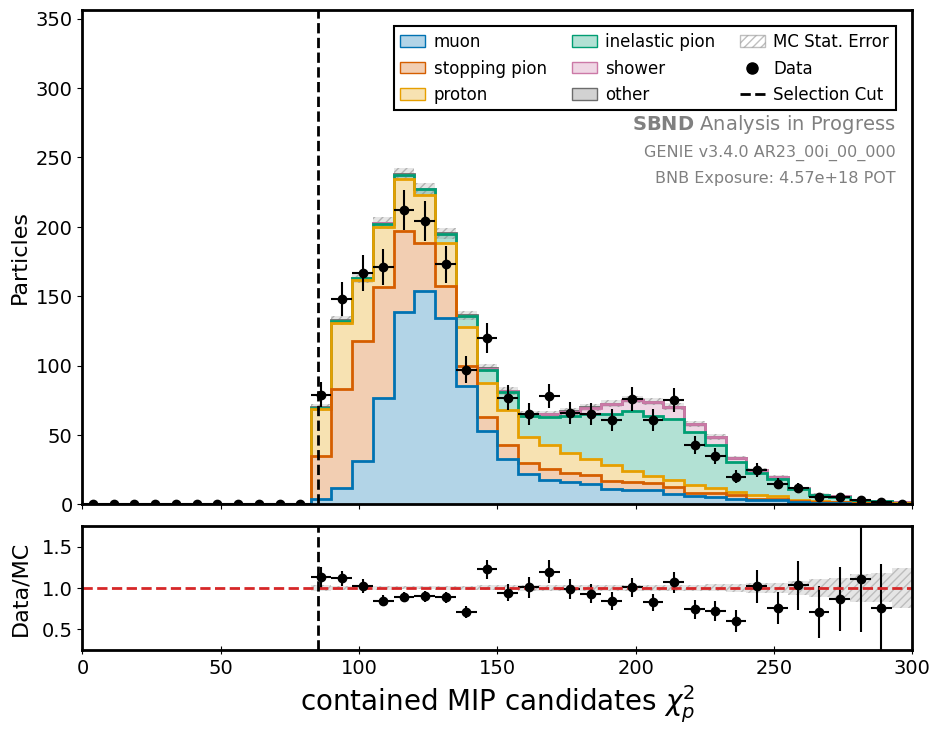

--- Processing Cut: proton_BDT ---


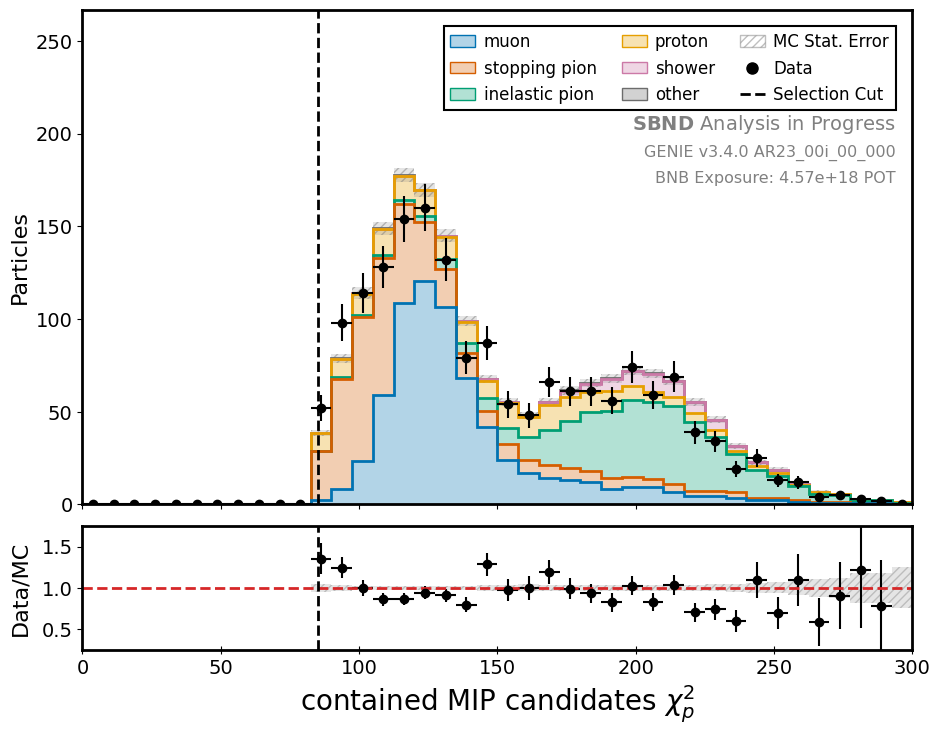

--- Processing Cut: containment ---


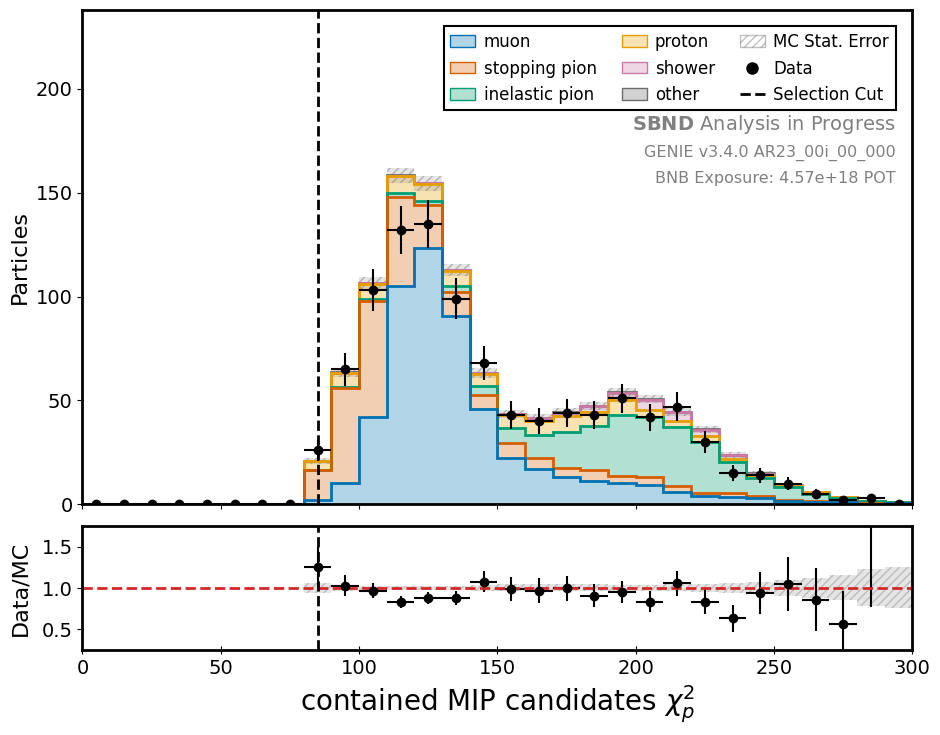

--- Processing Cut: michel ---


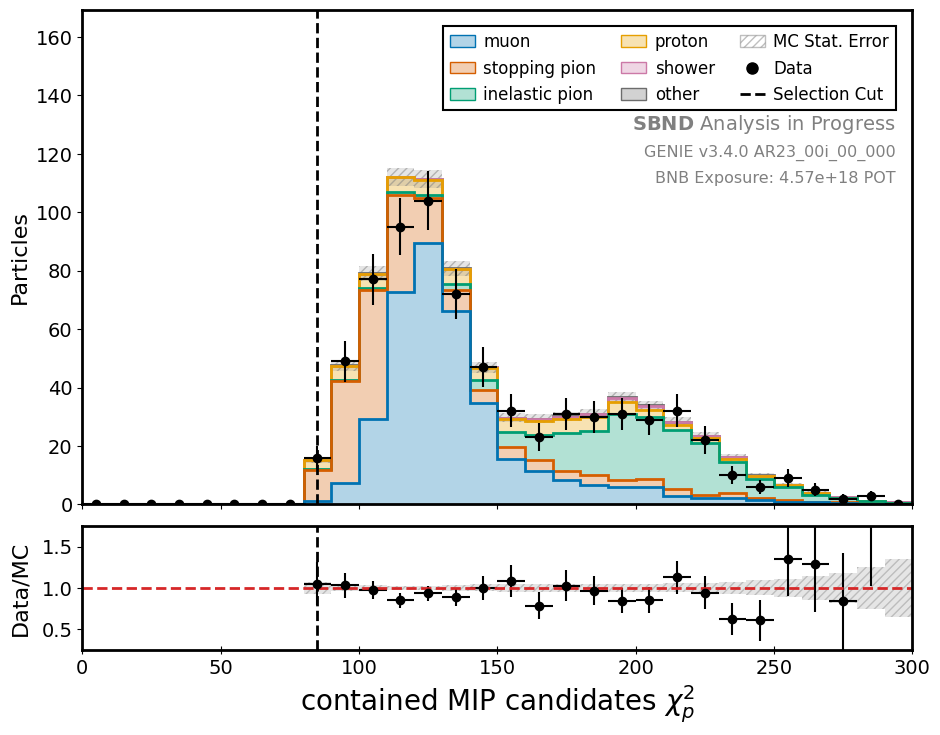

--- Processing Cut: extra_pion ---


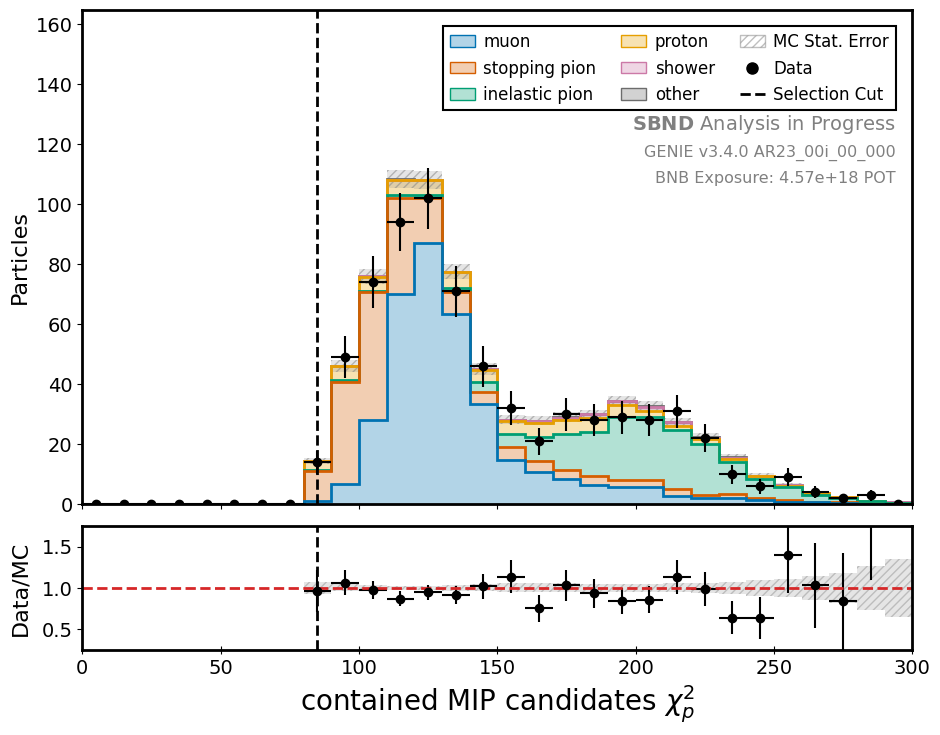

--- Processing Cut: energy ---


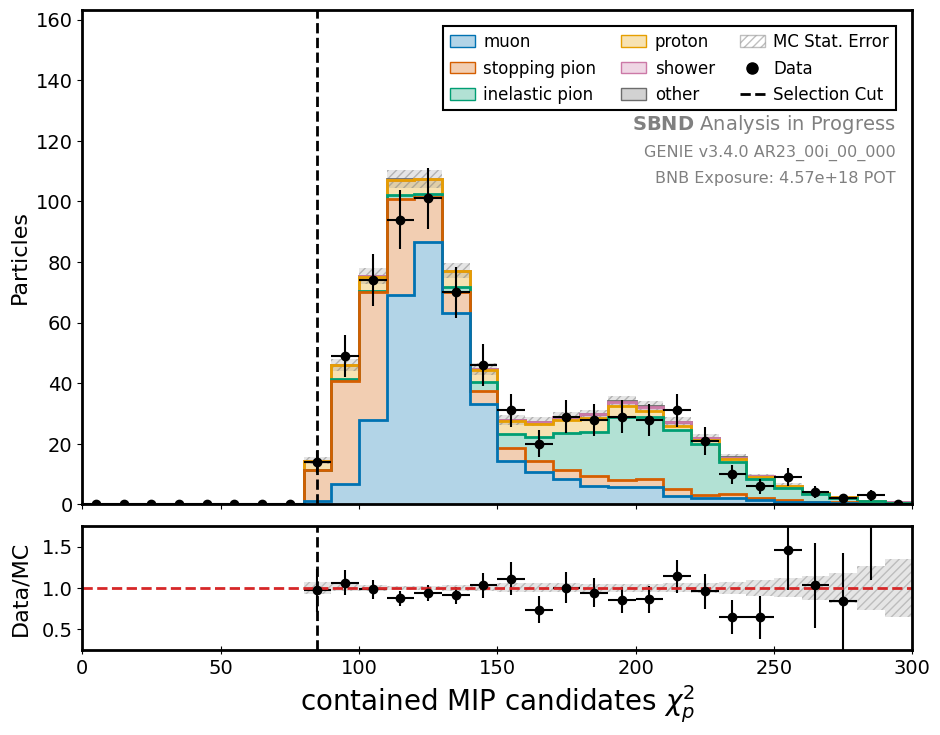

--- Processing Cut: energy ---


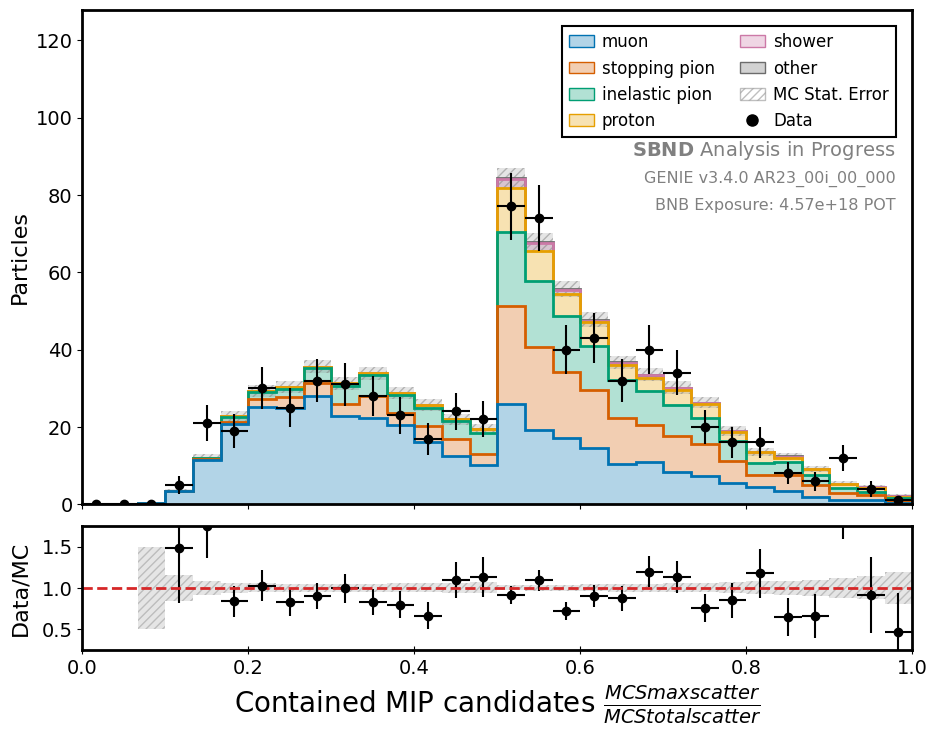

--- Processing Cut: angle ---


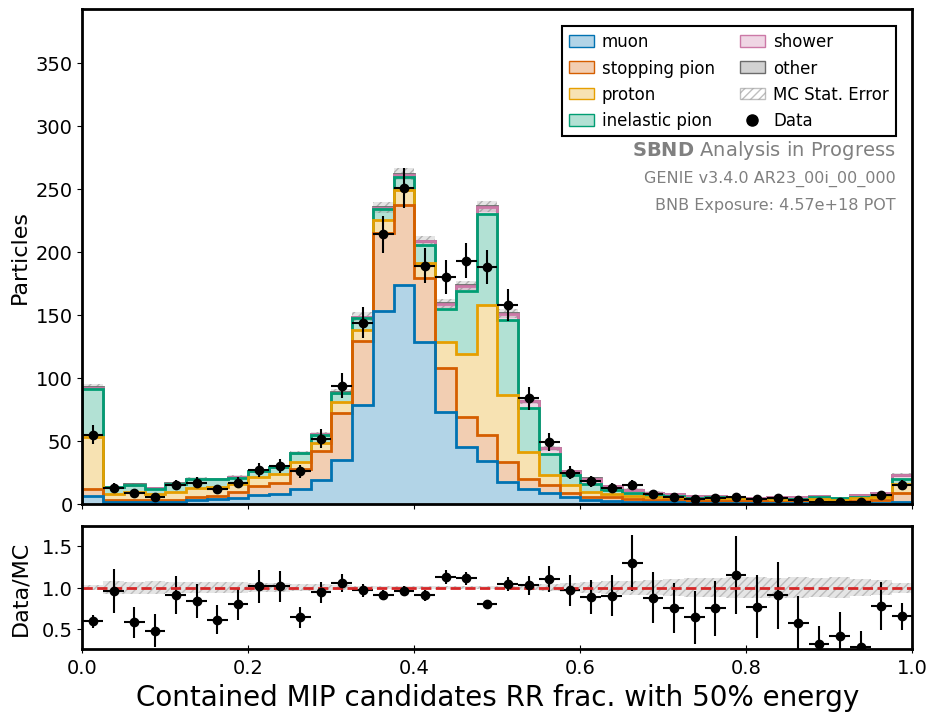

--- Processing Cut: angle ---


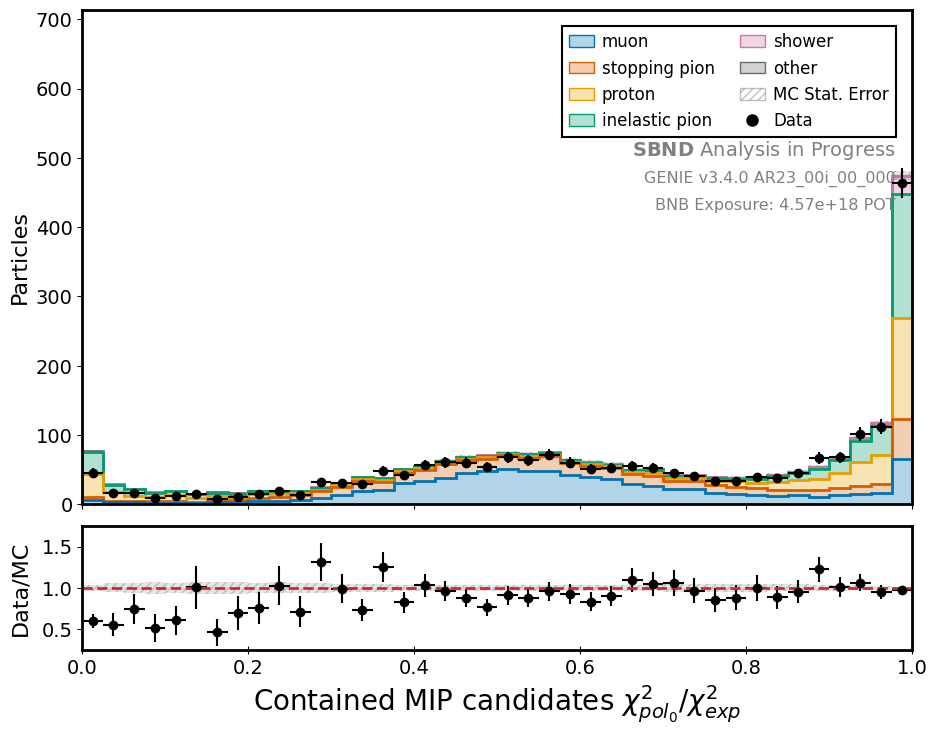

--- Processing Cut: proton_BDT ---


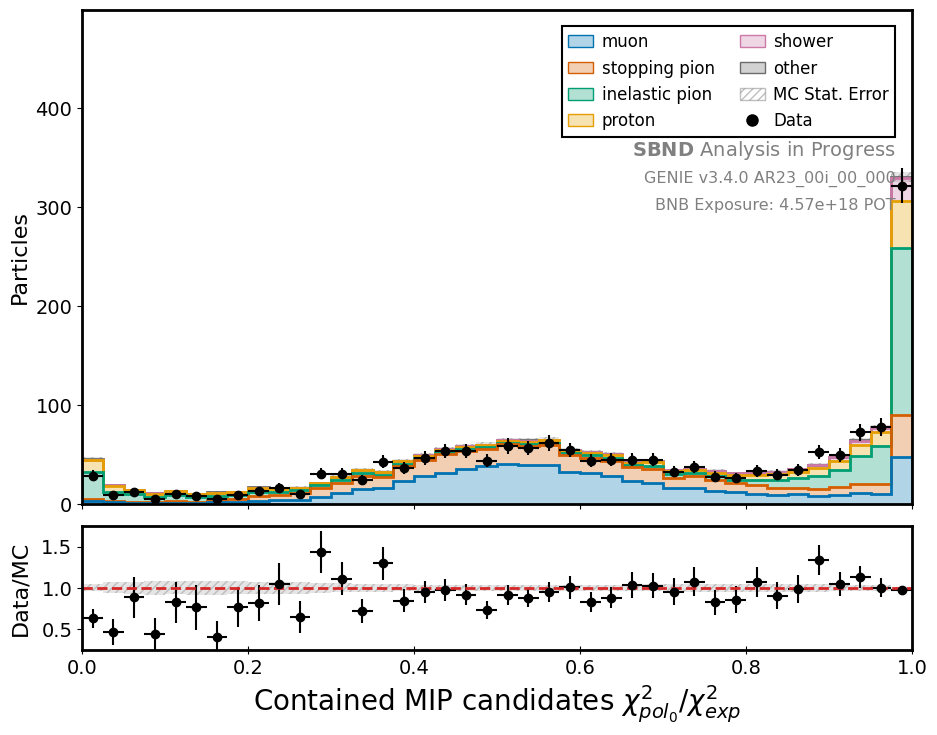

--- Processing Cut: containment ---


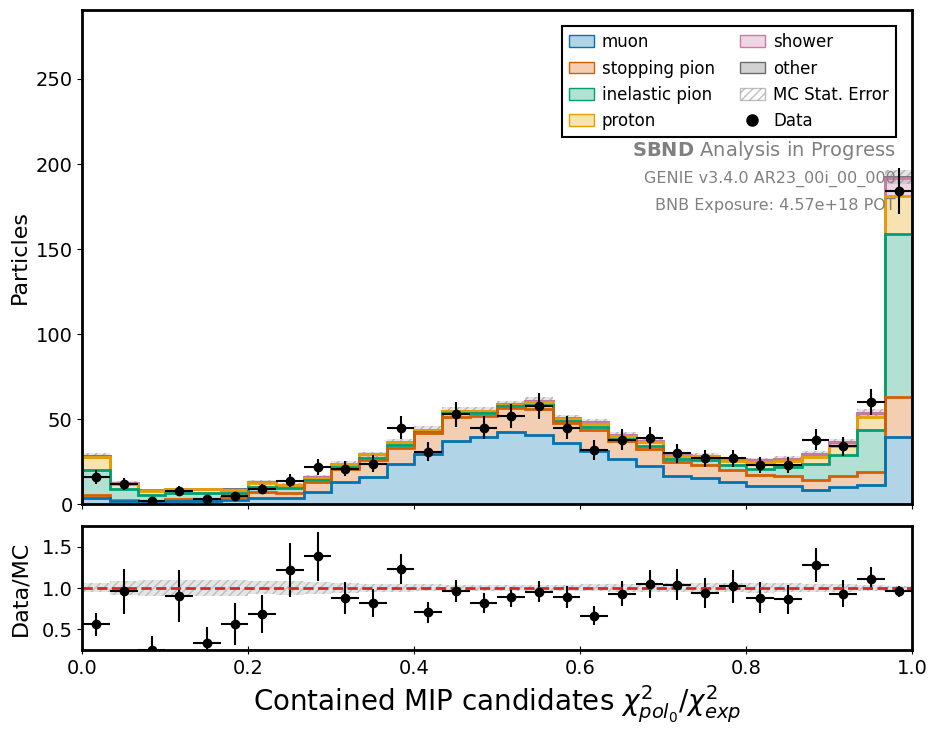

--- Processing Cut: michel ---


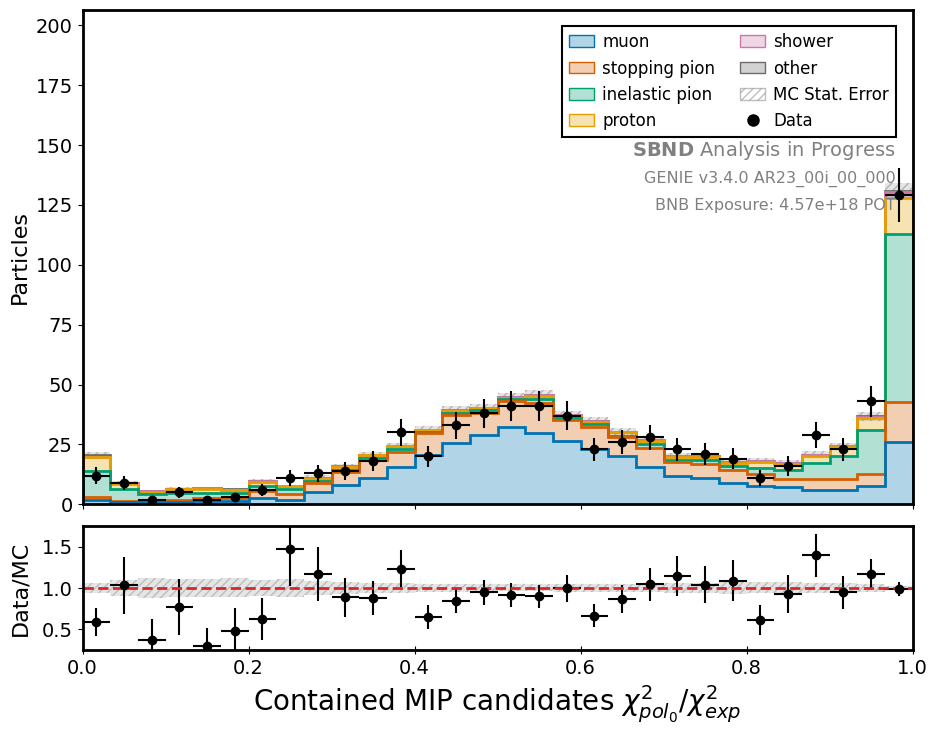

--- Processing Cut: extra_pion ---


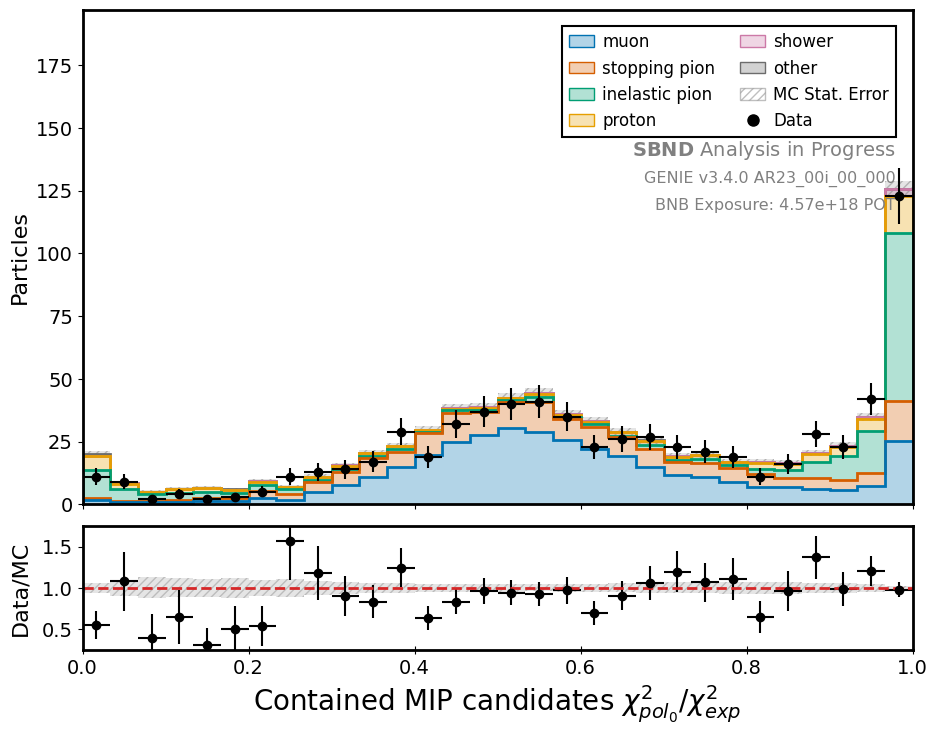

--- Processing Cut: energy ---


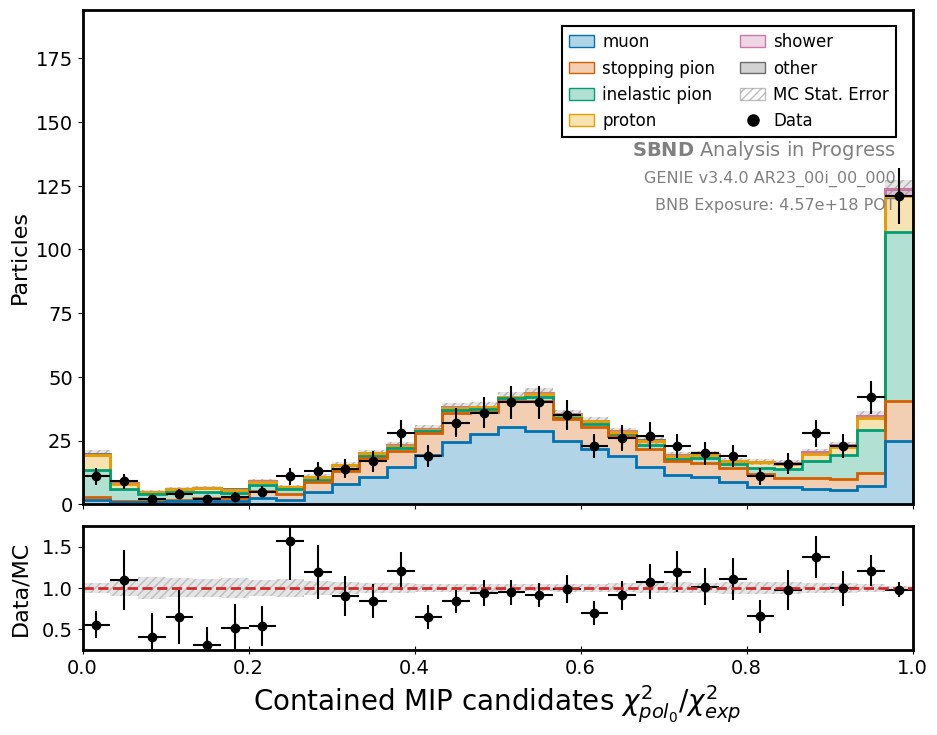

--- Processing Cut: angle ---


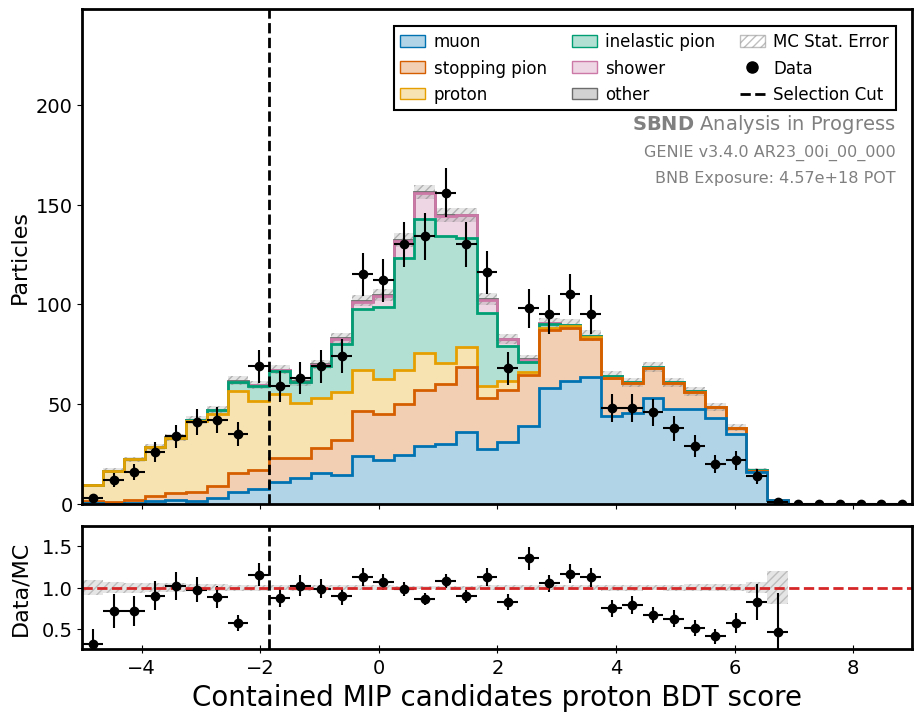

--- Processing Cut: proton_BDT ---


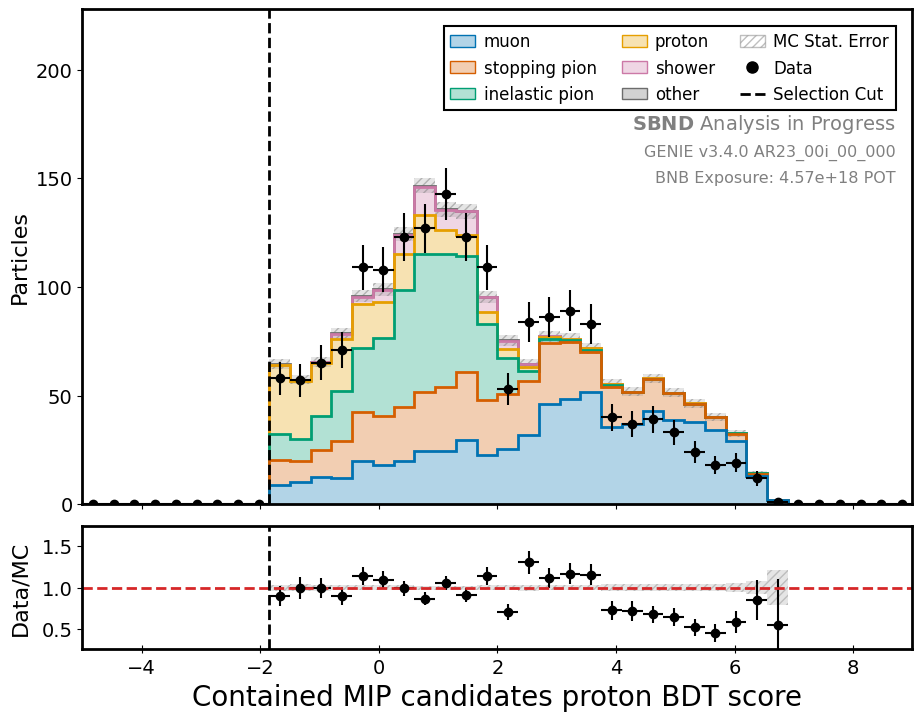

--- Processing Cut: containment ---


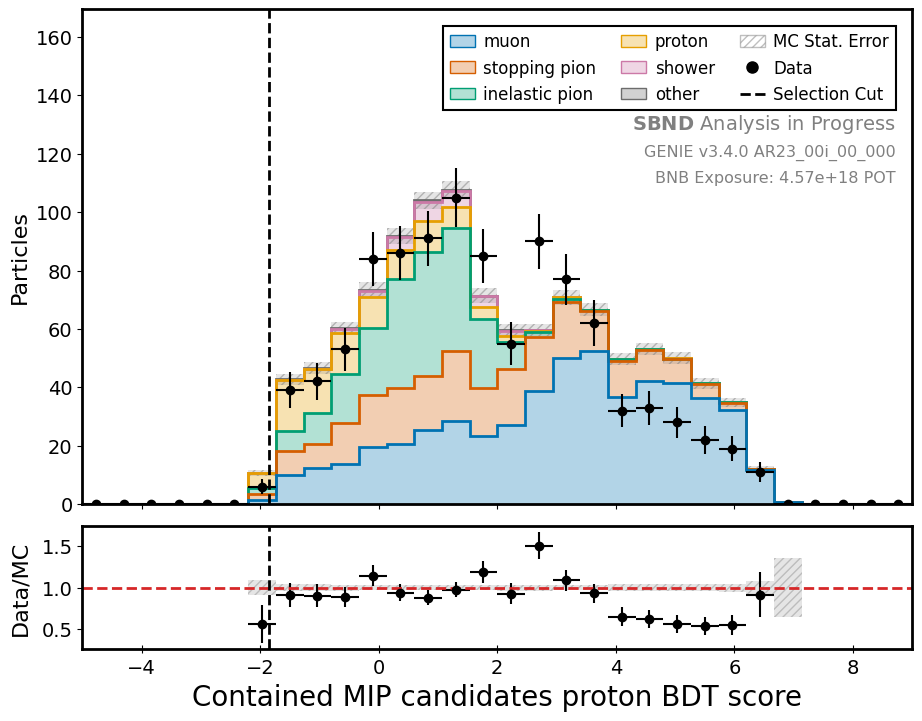

--- Processing Cut: michel ---


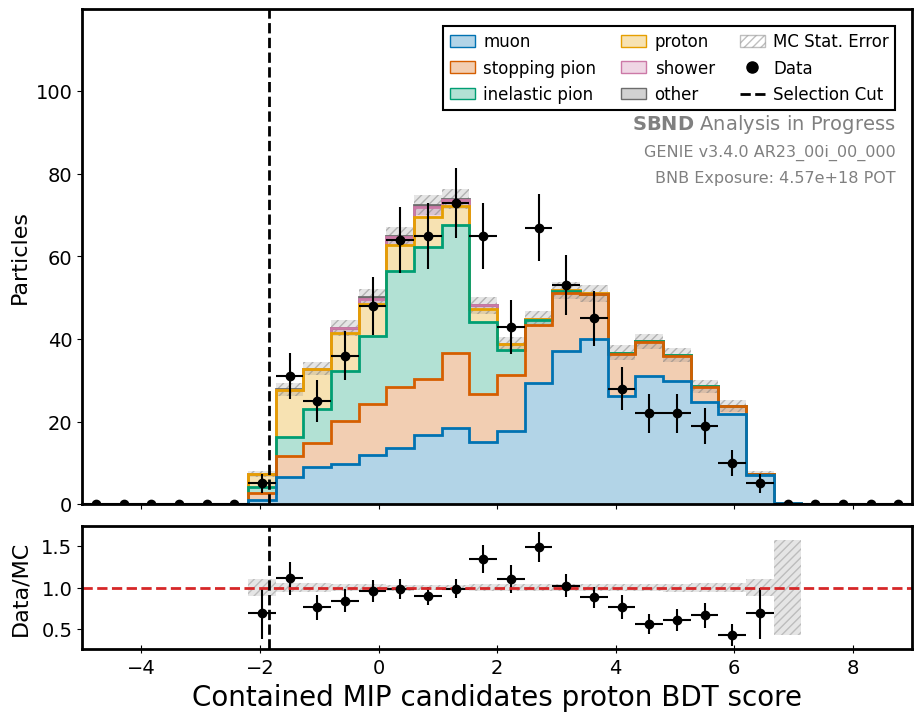

--- Processing Cut: extra_pion ---


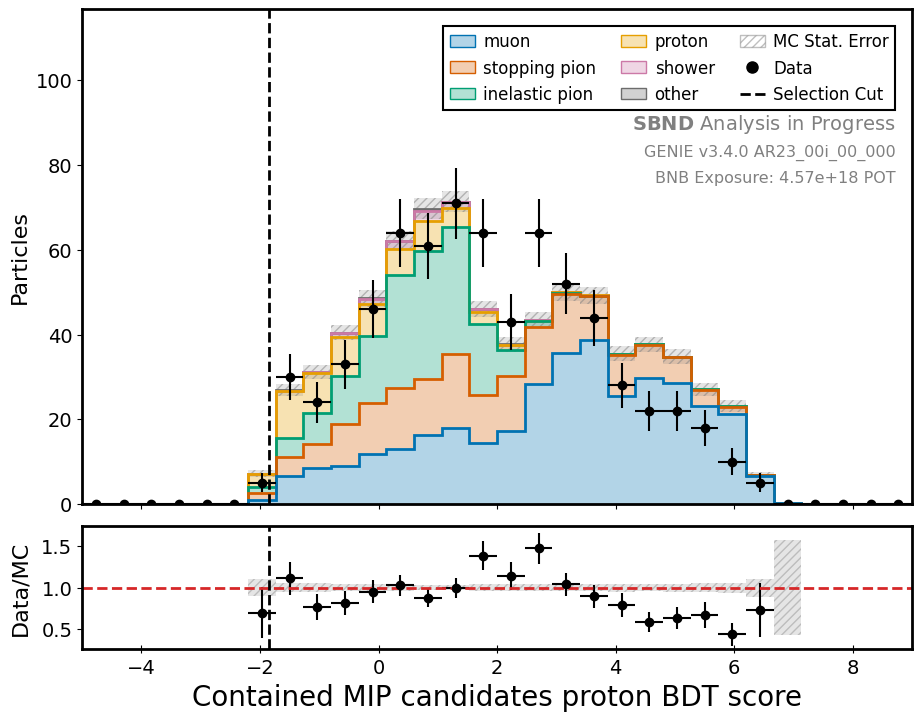

--- Processing Cut: energy ---


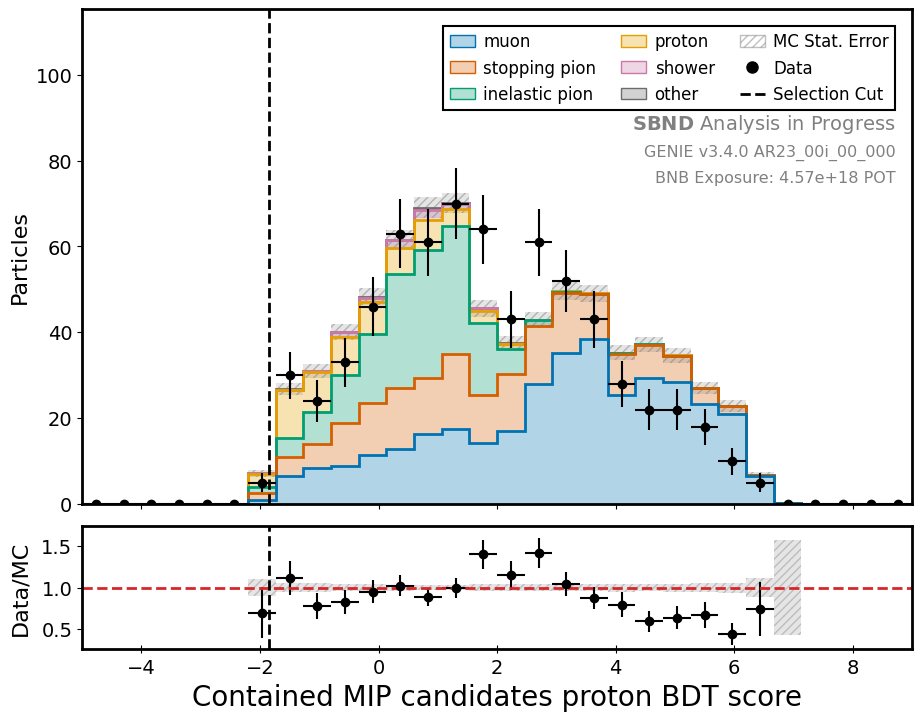

In [15]:
import os, shutil, tarfile
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd



config_vec =  particle_vars_vec  #+ measure_var_vec +  n_pfps_config_vec + simple_vars_vec_no_flash_time #+ TKI_genie_categ_vec + TKI_vec + 
WGT_COL = ('slc', 'wgt', '', '', '', '')
SLICE_LEVELS = ['__ntuple', 'entry', 'rec.slc..index']

# --- Main Analysis Loop ---
smaller_binning_cuts = ["containment","michel","extra_pion","energy"]

# --- Main Analysis Loop ---
for config in config_vec:
    idx_range = sorted([cuts.index(config.start_cut), cuts.index(config.end_cut)])
    selected_cuts = cuts[idx_range[0] : idx_range[1] + 1]

    for cut in selected_cuts:
        print(f"--- Processing Cut: {cut} ---")
        if cut in smaller_binning_cuts:
            config.bins = np.linspace(config.bins[0], config.bins[-1], 31)
            # Recompute bin centers so the array shape matches the new binning!
            config.bin_centers = 0.5 * (config.bins[:-1] + config.bins[1:])
        
        # 1. Prepare DataFrames
        curr_mc   = filter_df(mc_evt_df,   config.extra_mask, mc_cumulative_masks[cut],   config)
        curr_data = filter_df(data_evt_df, config.extra_mask, data_cumulative_masks[cut], config)
        
        # 2. Base Statistics
        ret       = signal_hists(evtdf=curr_mc, var_config=config, return_data=True, plot=False)
        cv_events = ret["nevts_allsel_reco"]
        ret_stats = get_stat_covariance_matrix(cv_events, ret["sum_w2_allsel_reco"])
        del ret

        total_cov      = ret_stats["cov"]       # we own this, no copy needed
        total_cov_frac = ret_stats["cov_frac"]
        frac_unc_list  = [(np.sqrt(np.diag(total_cov_frac)), "MC Stat")]
        del ret_stats

        fig, p_value = plot_stacked_histogram_with_ratio(
            mc_df=curr_mc, data_df=curr_data, config=config,
            cov_frac_matrix=total_cov_frac, cov_matrix=total_cov,
            title=f"{cut} - {config.file_name}", weight_column=WGT_COL,
            data_pot=data_tot_pot, normalize=False,
            show_stats=False, divide_by_bin_width=False, skip_bin_compression = True
        )
        del total_cov, total_cov_frac, curr_data, frac_unc_list